In [2]:
import numpy as np
from problems.QP_with_Lasso import QP_with_Lasso
from problems.square_root_Lasso import Square_Root_Lasso
from problems.sparse_logistic_regression import Sparse_Logistic_Regression
from problems.random_large_QP import Random_Large_QP

import matplotlib.pyplot as plt
import pandas as pd

from first_order_methods import First_Order_Methods
from libsvmdata import fetch_libsvm
import pickle

/Users/litianjiao/opt/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/image.py:167: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  dtype=np.int):


# Quadratic programming

In [7]:
dataset = "cadata"
A_raw, b_raw = fetch_libsvm(dataset)
A = A_raw/A_raw.std()
b = b_raw/A_raw.std()
qwl = QP_with_Lasso(A, b, 0.00)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))

gamma: 0.000000
initial function value: 35298.353762


AC-FGM: k=250000, alpha=0.100, beta=0.184
Done: 327.282 seconds
-----------------------------------
FISTA: k=250000
Done: 629.942 seconds
-----------------------------------
FISTA: k=250000
Done: 622.587 seconds
-----------------------------------
AC-FGM: k=250000, alpha=0.100, beta=0.184
Done: 337.681 seconds
-----------------------------------


/Users/litianjiao/opt/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


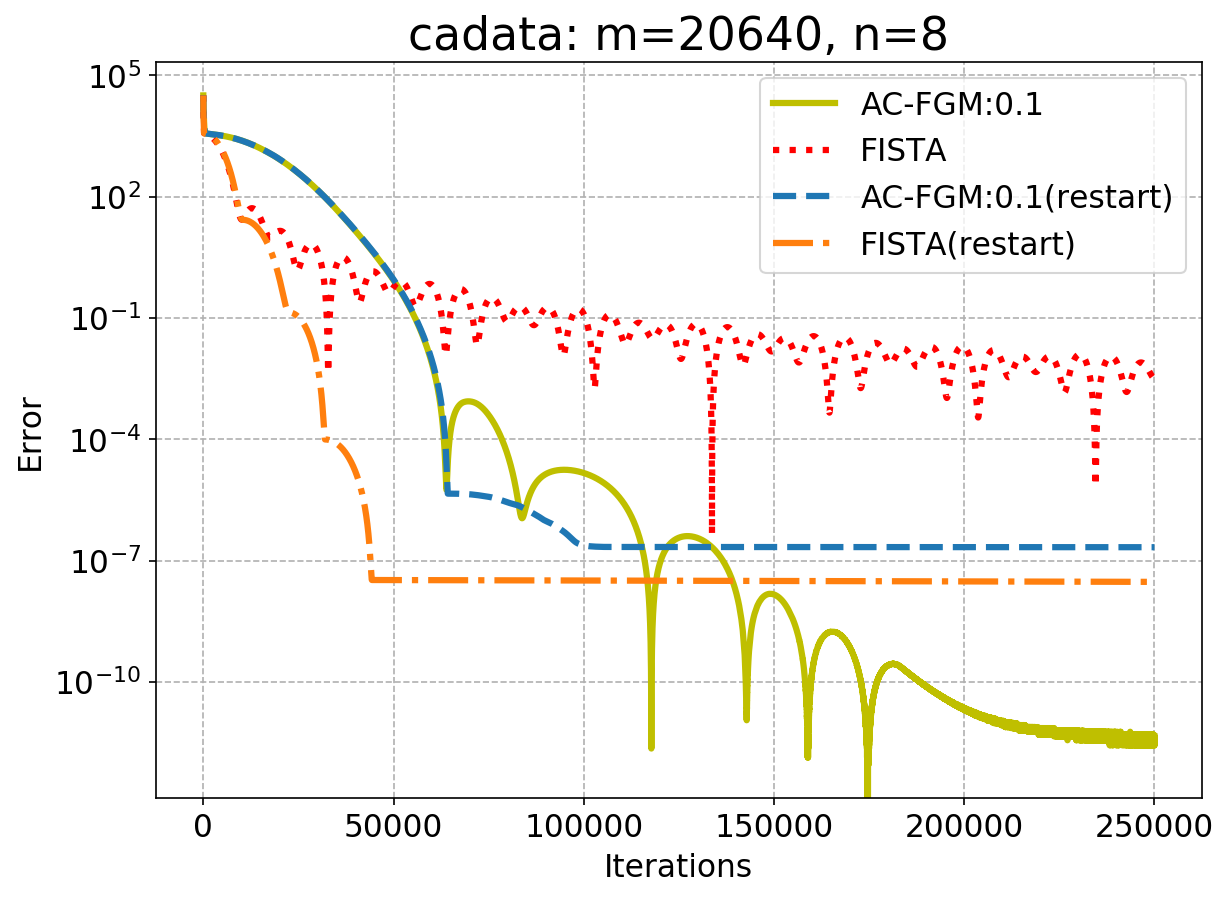

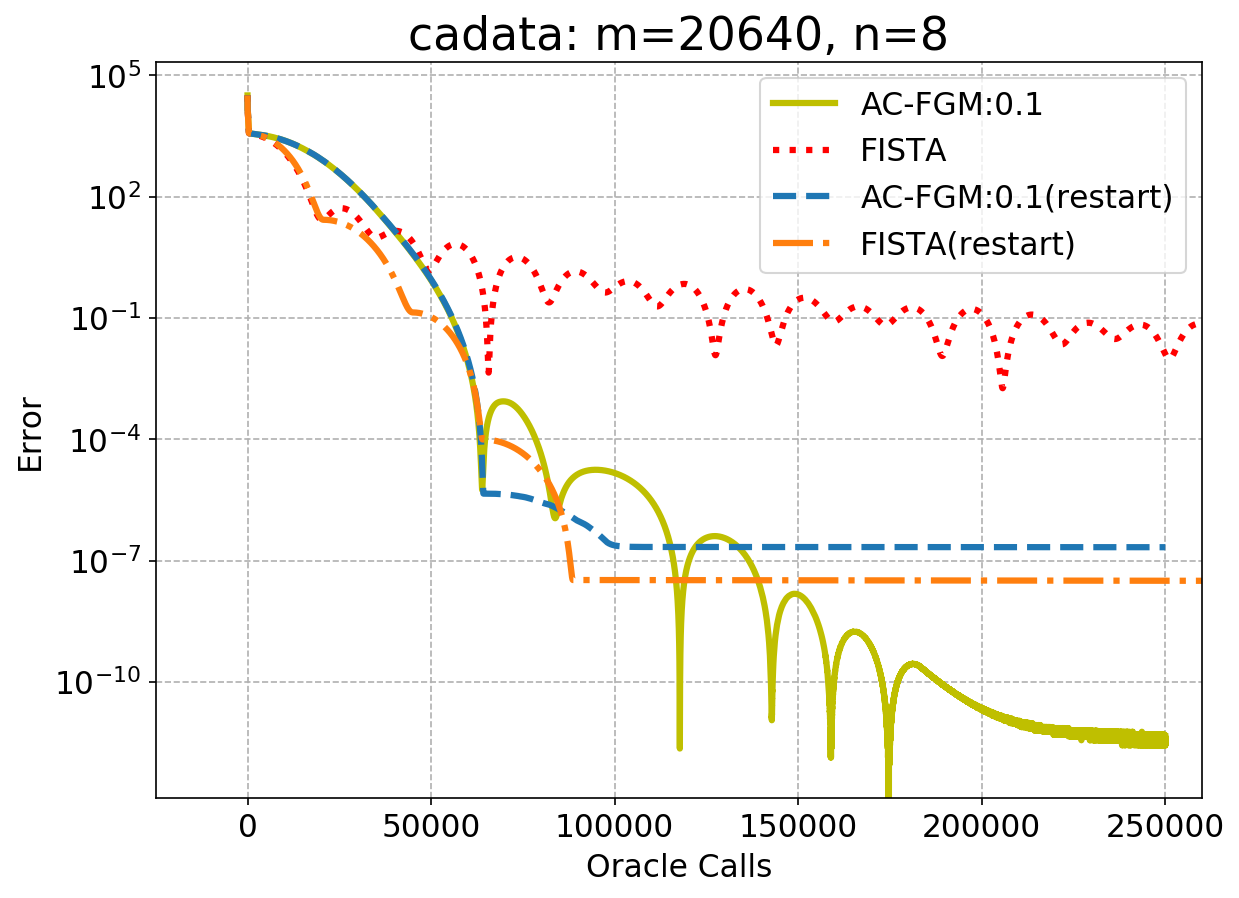

In [8]:
result_cadata = fom.test_all_methods_smooth_adaptive_restart(k=250000, beta=0.184, draw_performance_plot=True, dataset="cadata: m=20640, n=8", initial_line_search=False, right_lim=260000)
with open('QP_cadata_restart.pkl', 'wb') as f:  
    pickle.dump(result_cadata, f)

In [9]:
dataset = "bodyfat"
A, b = fetch_libsvm(dataset)
qwl = QP_with_Lasso(A, b, 0.00)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))

gamma: 0.000000
initial function value: 1.114597


AC-FGM: k=40000, alpha=0.100, beta=0.184
Done: 1.999 seconds
-----------------------------------
FISTA: k=40000
Done: 2.092 seconds
-----------------------------------
FISTA: k=40000
Done: 2.122 seconds
-----------------------------------
AC-FGM: k=40000, alpha=0.100, beta=0.184
Done: 2.015 seconds
-----------------------------------


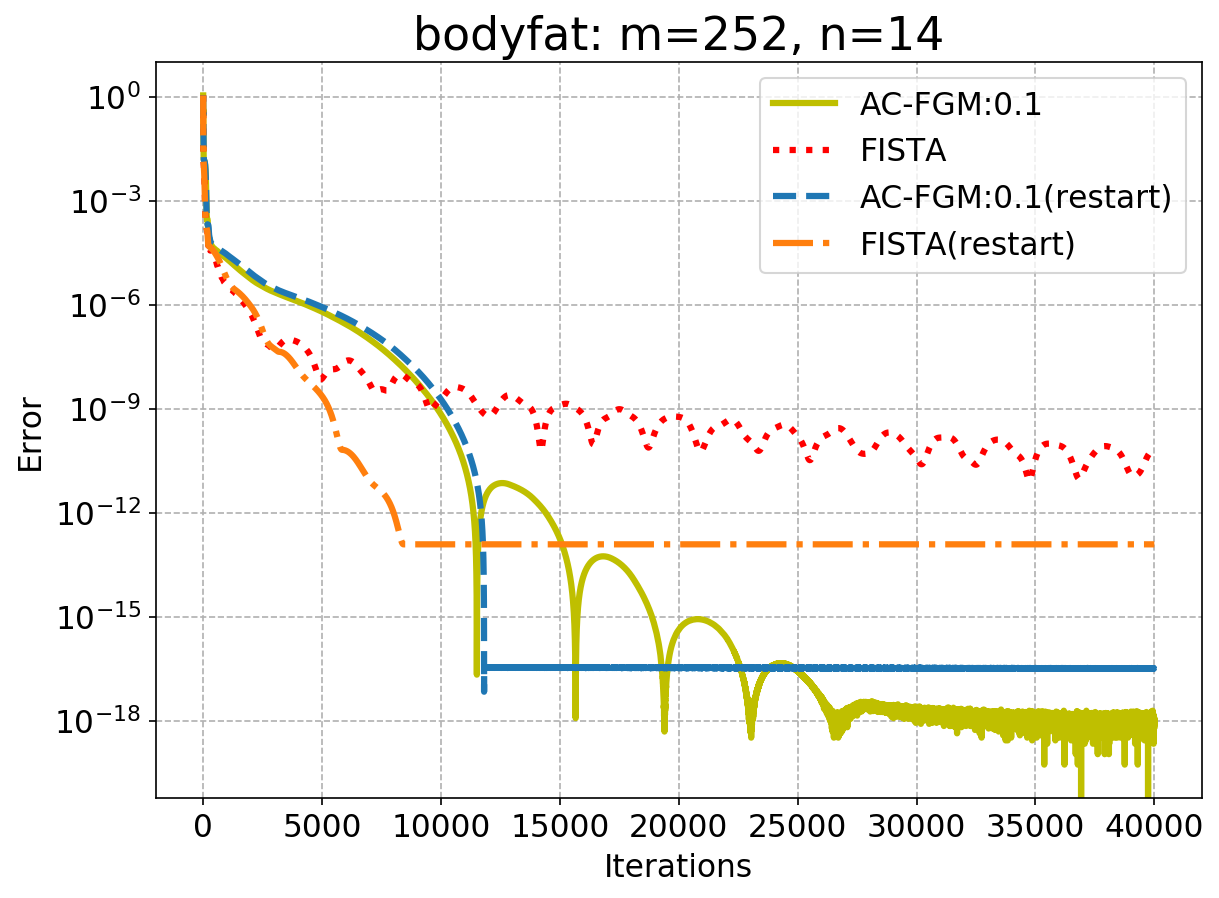

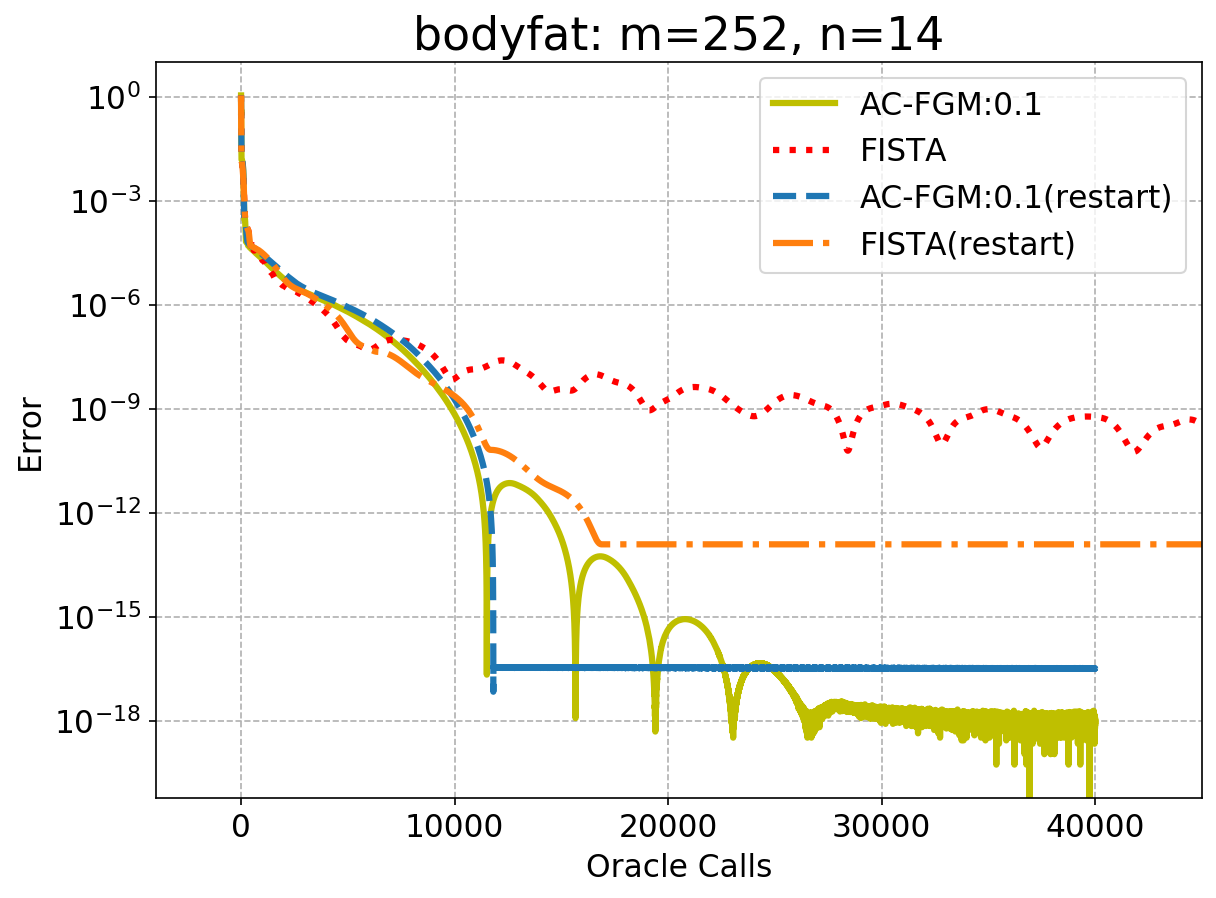

In [10]:
result_bodyfat = fom.test_all_methods_smooth_adaptive_restart(k=40000, beta=0.184, draw_performance_plot=True, dataset="bodyfat: m=252, n=14", initial_line_search=False, right_lim=45000)
with open('QP_bodyfat_restart.pkl', 'wb') as f:  
    pickle.dump(result_bodyfat, f)

# Lasso

gamma: 0.000131
initial function value: 1.000000
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 519.140 seconds
-----------------------------------
FISTA: k=10000
Done: 807.394 seconds
-----------------------------------
FISTA: k=10000
Done: 809.280 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 523.931 seconds
-----------------------------------


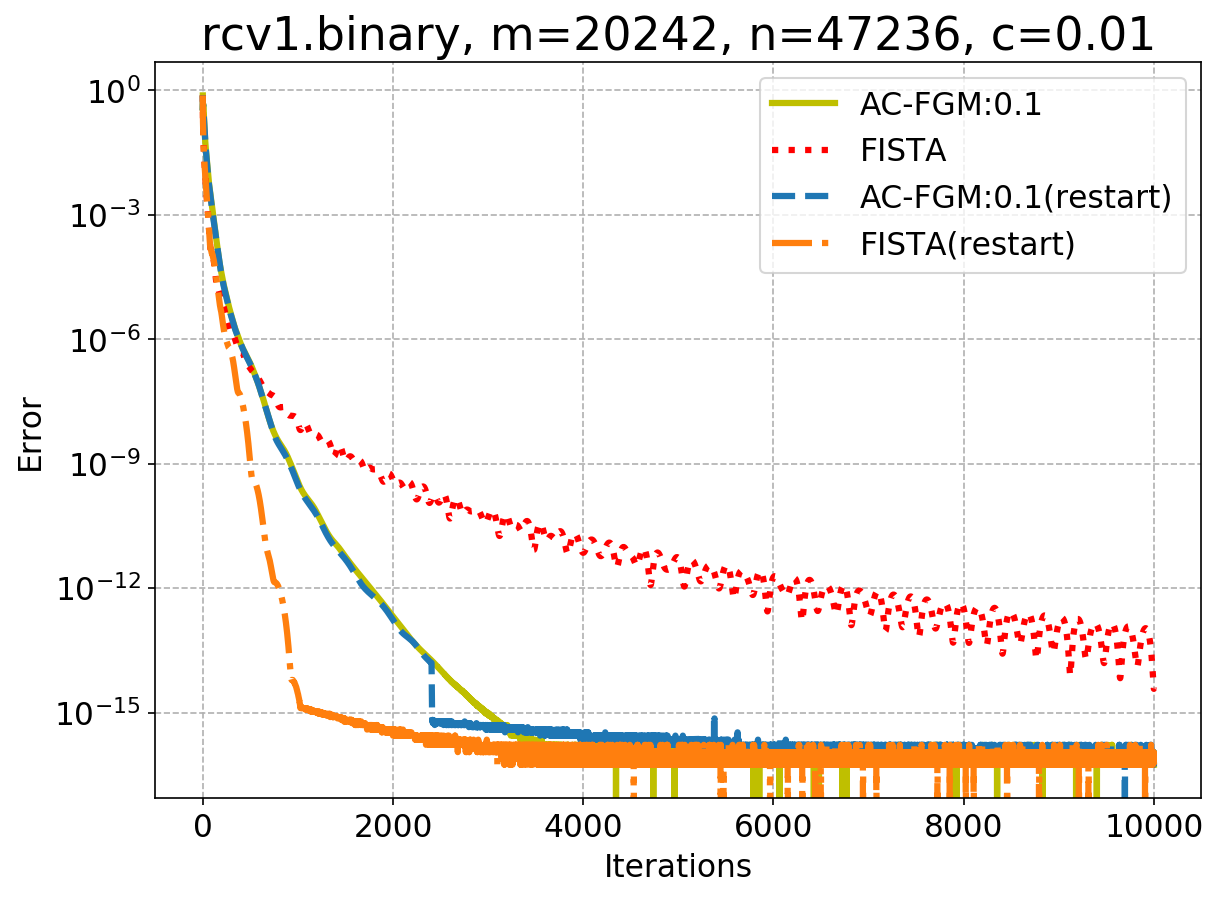

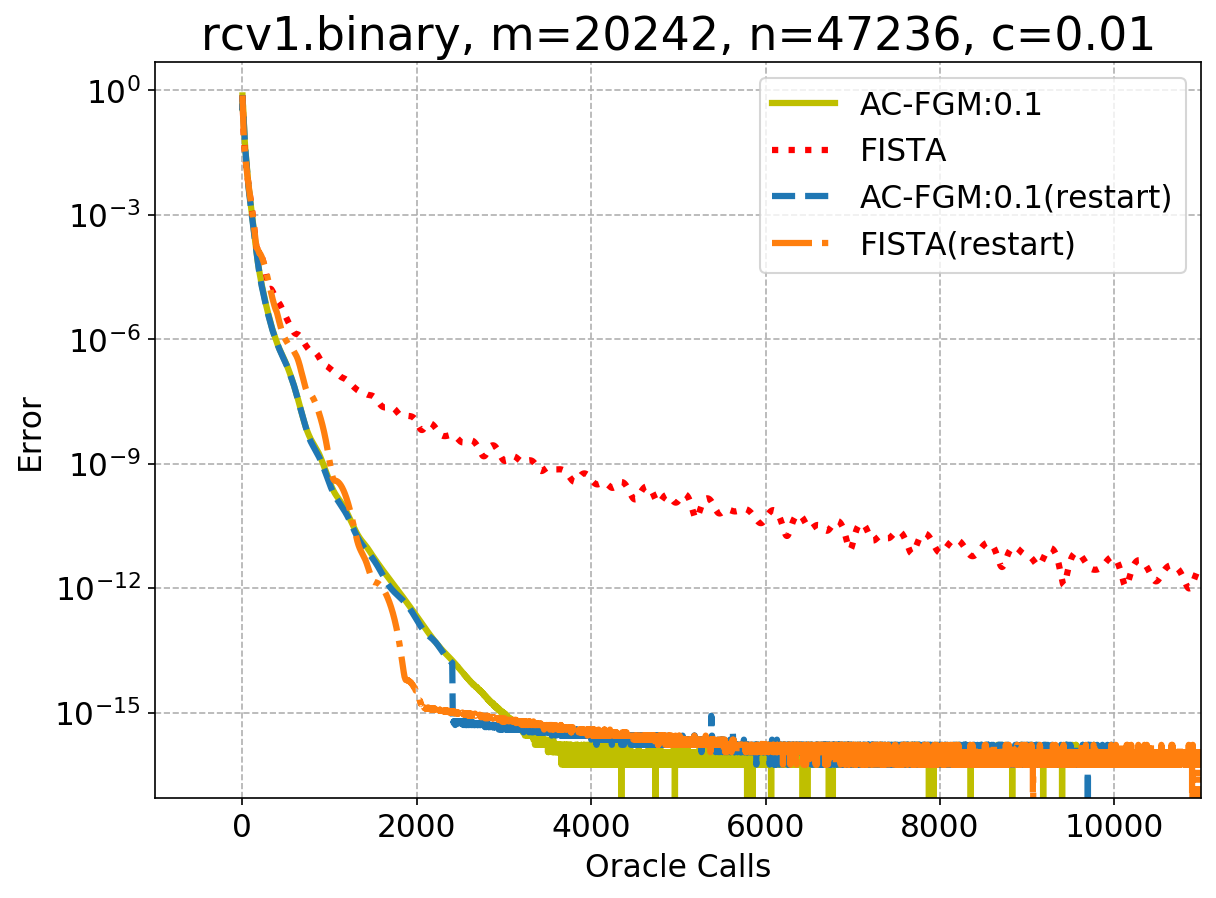

In [11]:
print("========================")
A, b = fetch_libsvm("rcv1.binary")
qwl = QP_with_Lasso(A, b, 0.01)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))
print("------------------------")
result_rcv = fom.test_all_methods_smooth_adaptive_restart(k=10000, beta=0.184, draw_performance_plot=True, dataset="rcv1.binary, m=20242, n=47236, c=0.01", initial_line_search=False, right_lim=11000)
with open('lasso_rcv_adaptive_restart_01.pkl', 'wb') as f: 
    pickle.dump(result_rcv, f)

gamma: 0.000013
initial function value: 1.000000
------------------------
AC-FGM: k=30000, alpha=0.100, beta=0.184
Done: 1590.897 seconds
-----------------------------------
FISTA: k=30000
Done: 2448.324 seconds
-----------------------------------
FISTA: k=30000
Done: 2444.832 seconds
-----------------------------------
AC-FGM: k=30000, alpha=0.100, beta=0.184
Done: 1583.218 seconds
-----------------------------------


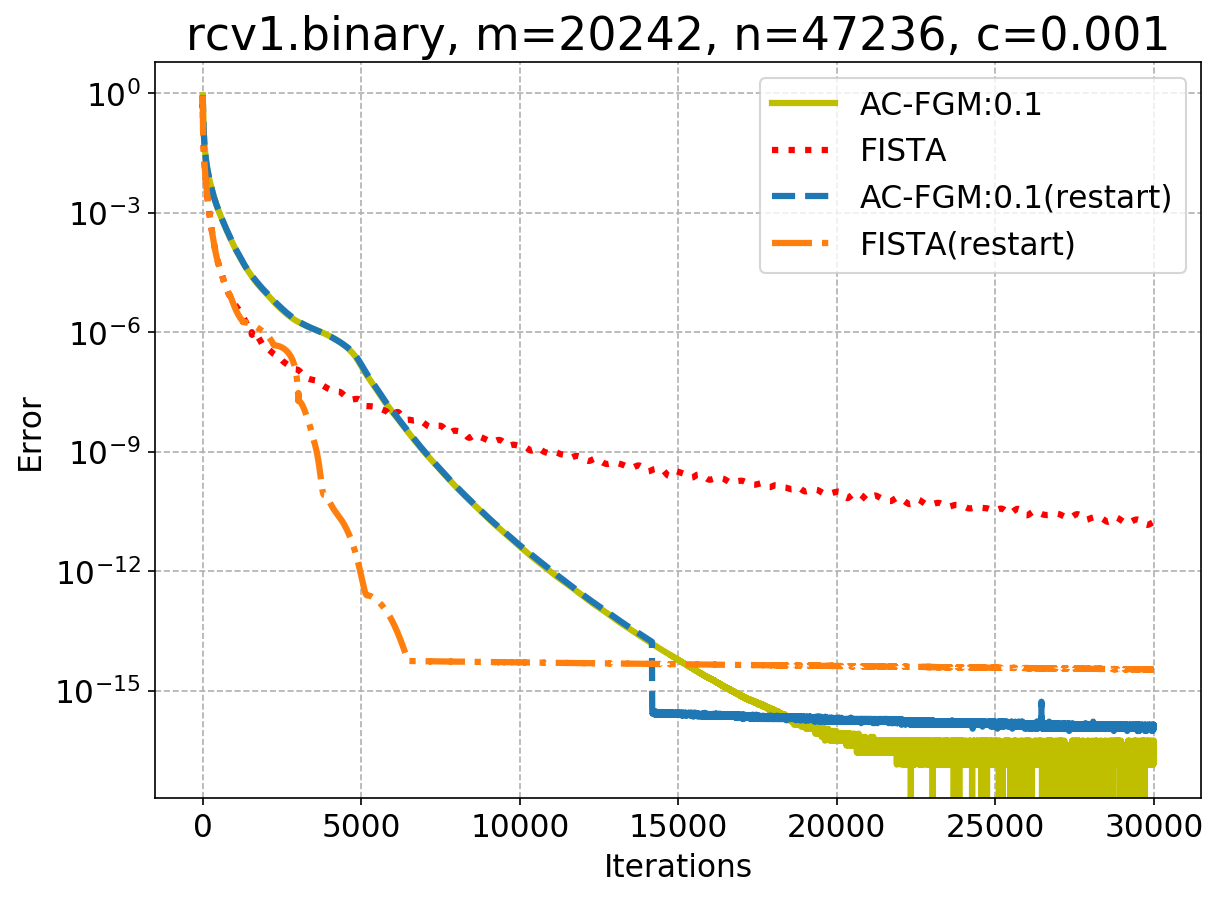

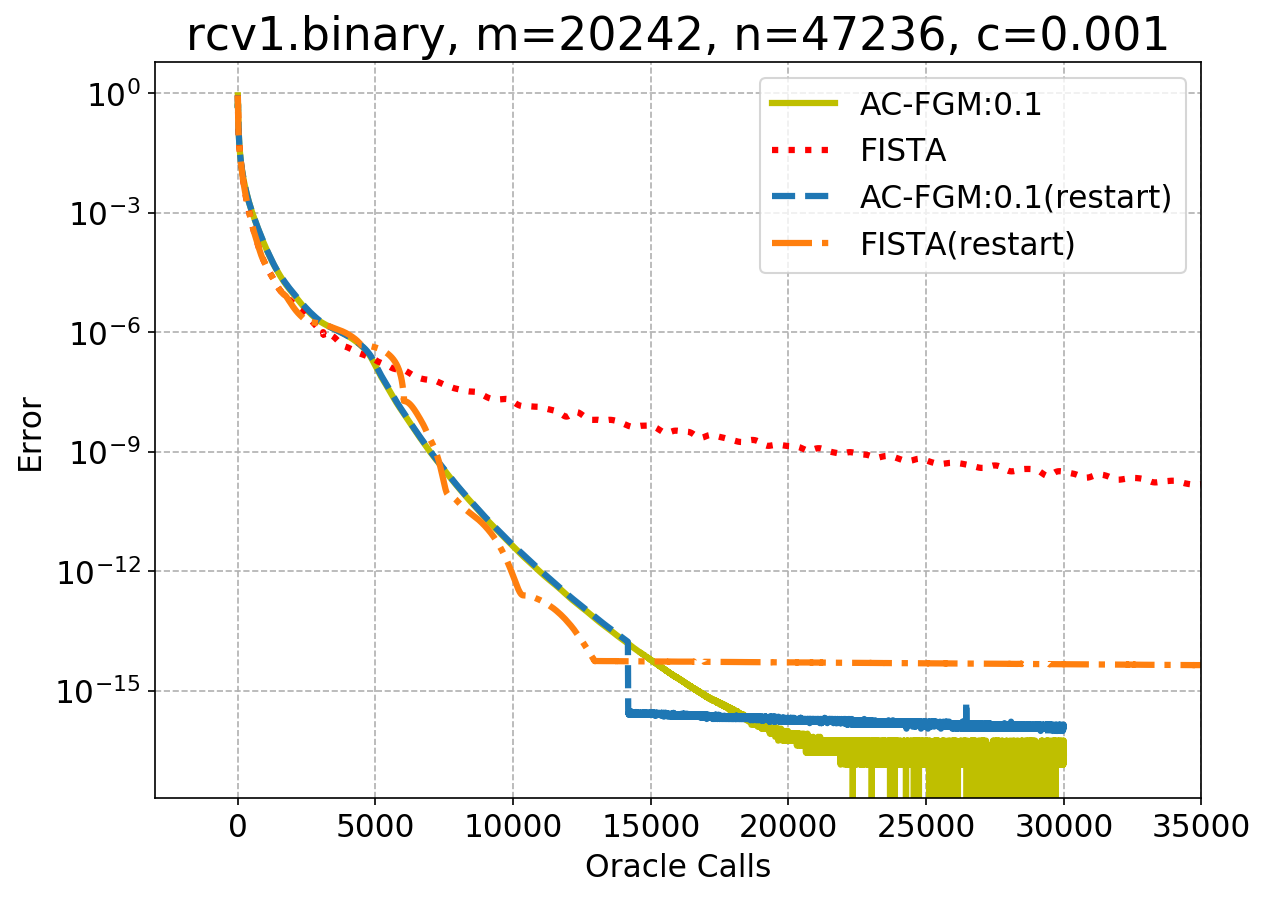

In [12]:
dataset = "rcv1.binary"
c = 0.001
k = 30000
right_lim = 35000
title = "rcv1.binary, m=20242, n=47236, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
qwl = QP_with_Lasso(A, b, c)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))
print("------------------------")
result_rcv_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('lasso_rcv_restart_001.pkl', 'wb') as f:  
    pickle.dump(result_rcv_2, f)

gamma: 0.000653
initial function value: 1.000000
------------------------
AC-FGM: k=7000, alpha=0.100, beta=0.184
Done: 370.995 seconds
-----------------------------------
FISTA: k=7000
Done: 566.066 seconds
-----------------------------------
FISTA: k=7000
Done: 565.610 seconds
-----------------------------------
AC-FGM: k=7000, alpha=0.100, beta=0.184
Done: 369.744 seconds
-----------------------------------


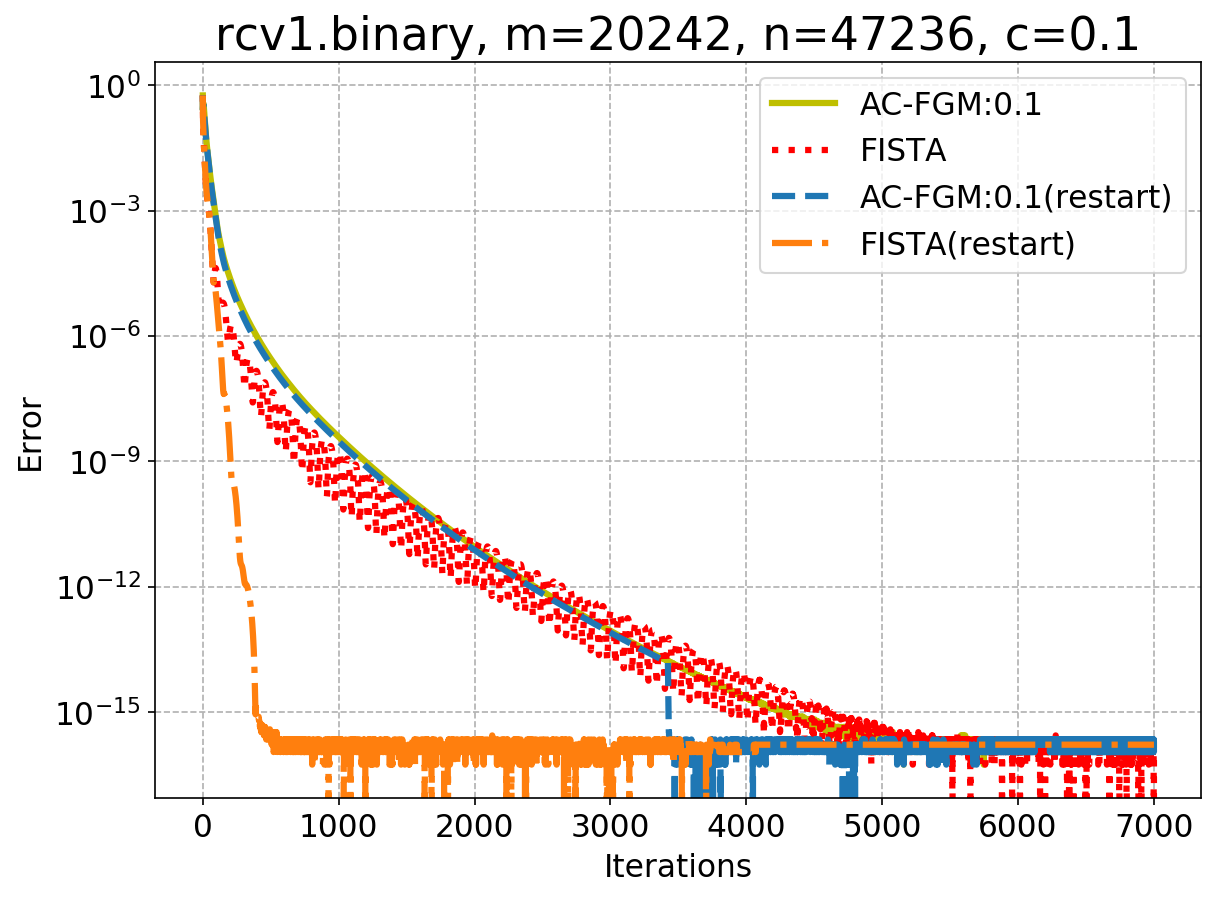

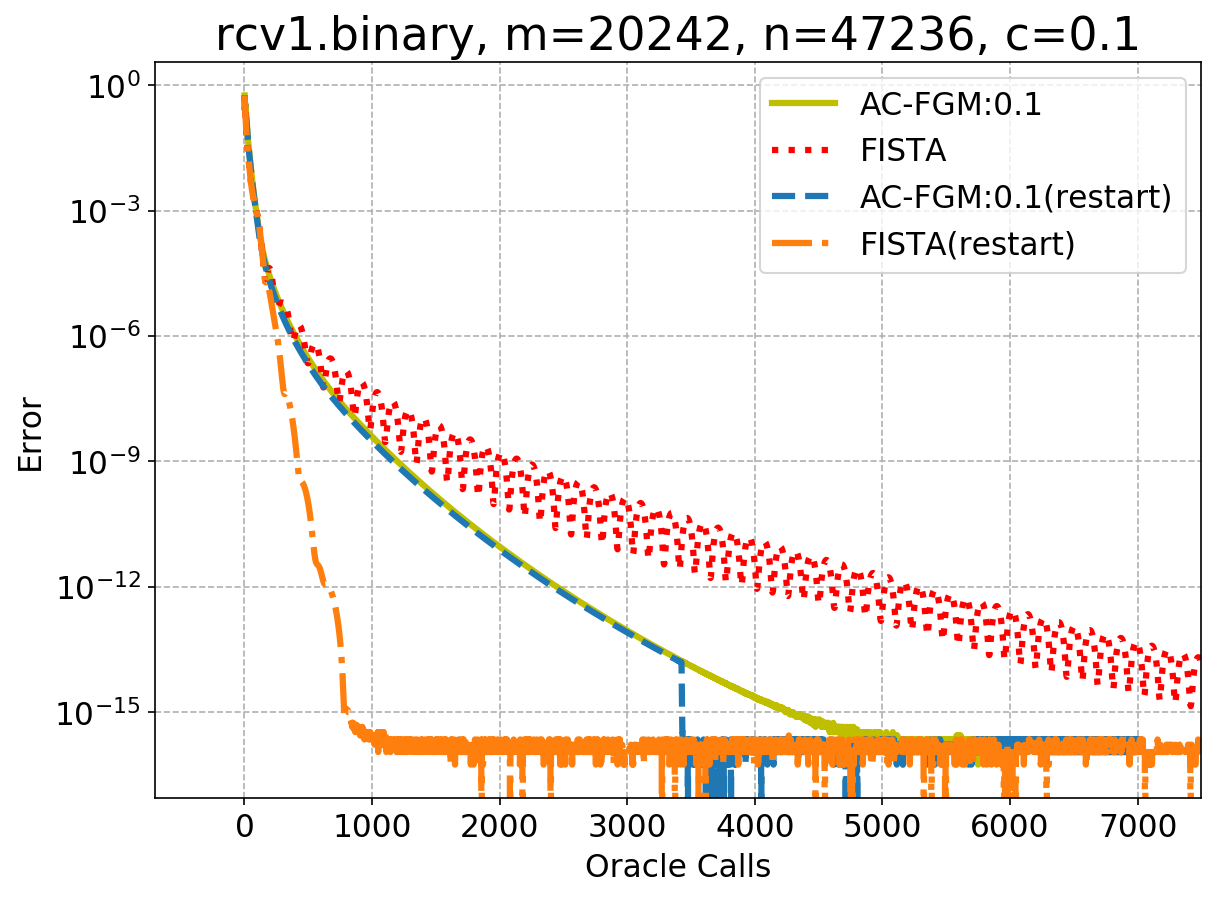

In [13]:
dataset = "rcv1.binary"
c = 0.05
k = 7000
right_lim = 7500
title = "rcv1.binary, m=20242, n=47236, c=0.1"

print("========================")
A, b = fetch_libsvm(dataset)
qwl = QP_with_Lasso(A, b, c)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))
print("------------------------")
result_rcv_3 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('lasso_rcv_05_restart.pkl', 'wb') as f:  
    pickle.dump(result_rcv_3, f)

gamma: 0.002675
initial function value: 1.000000
------------------------
AC-FGM: k=50000, alpha=0.100, beta=0.184
Done: 2628.226 seconds
-----------------------------------
FISTA: k=50000
Done: 5629.323 seconds
-----------------------------------
FISTA: k=50000
Done: 5810.881 seconds
-----------------------------------
AC-FGM: k=50000, alpha=0.100, beta=0.184
Done: 2689.203 seconds
-----------------------------------


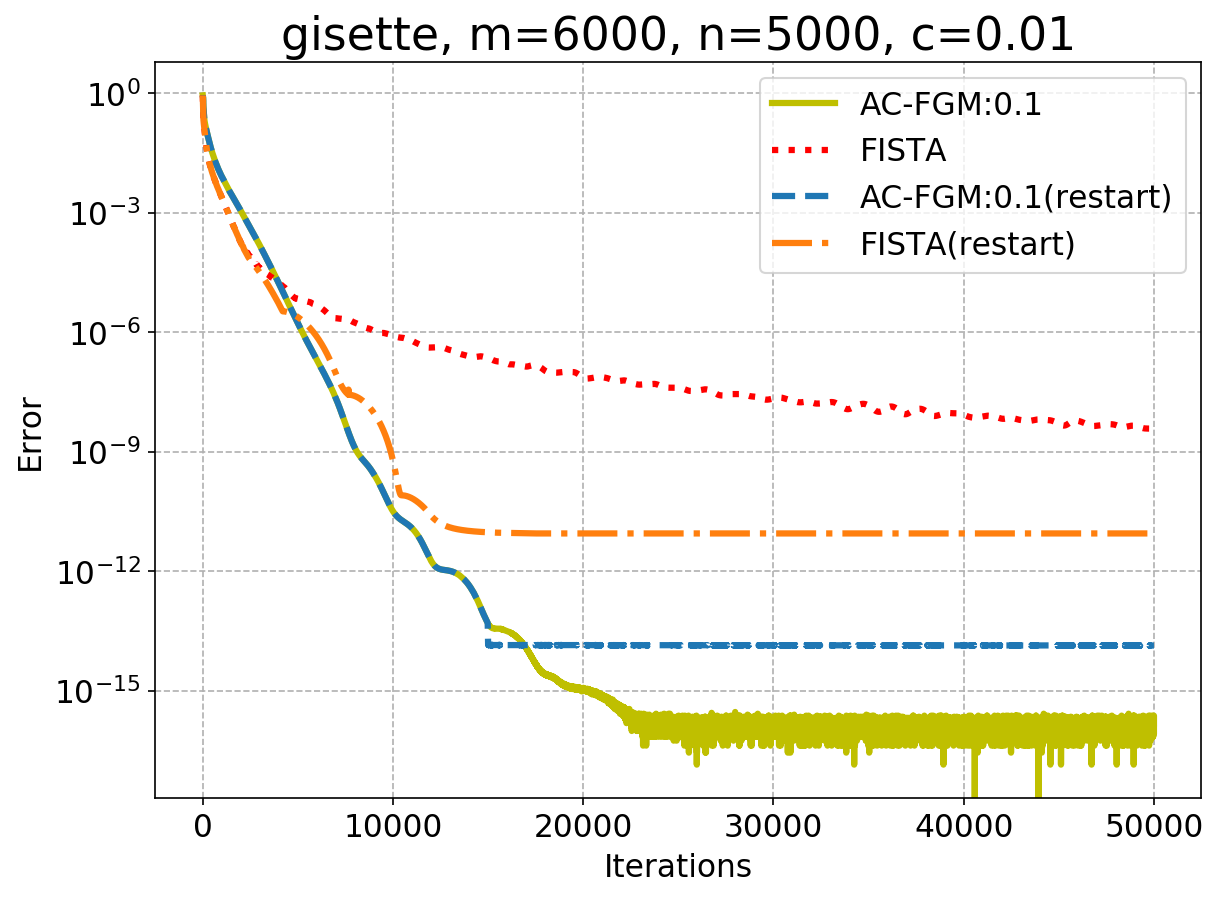

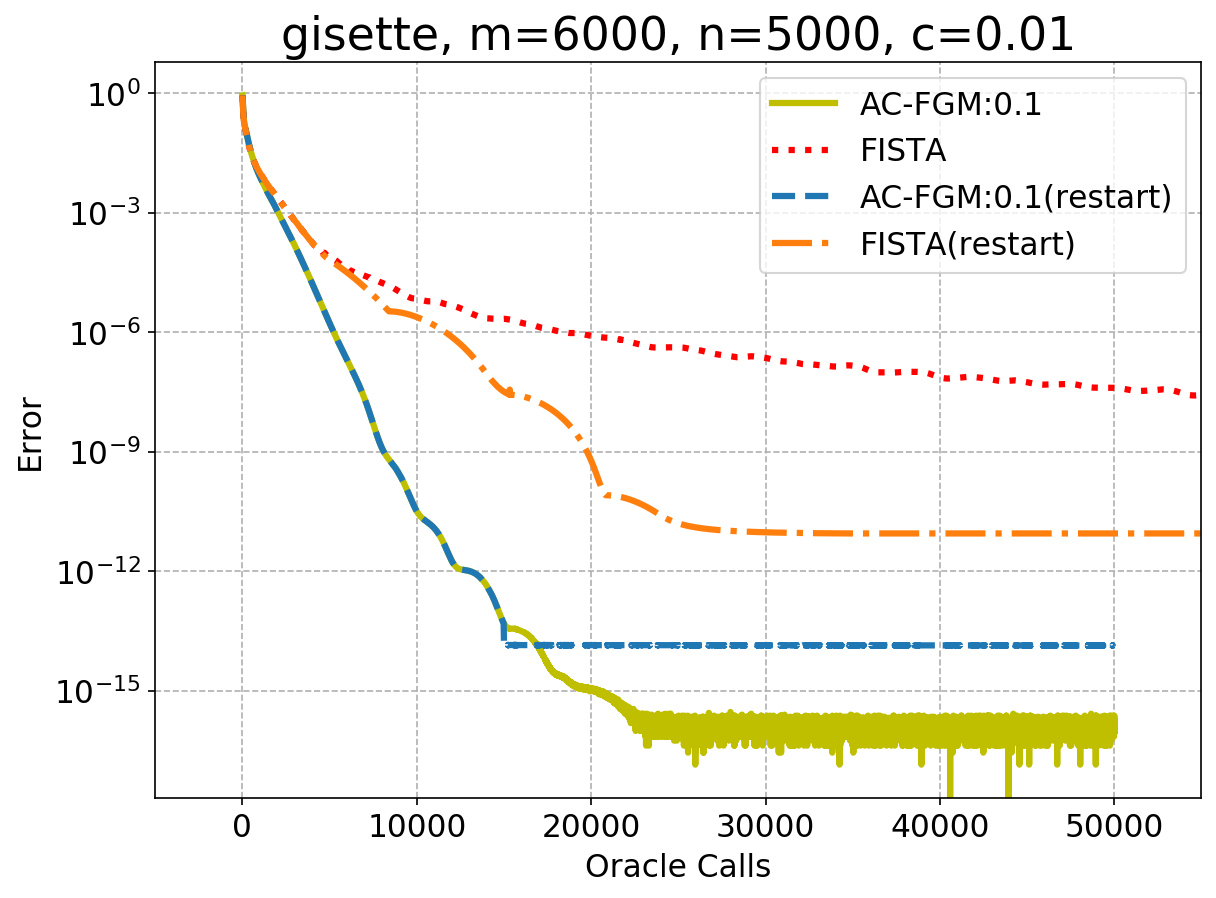

In [14]:
dataset = "gisette"
c = 0.01
k = 50000
right_lim = 55000
title = "gisette, m=6000, n=5000, c=0.01"

print("========================")
A, b = fetch_libsvm(dataset)
qwl = QP_with_Lasso(A, b, c)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))
print("------------------------")
result_gisette = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('lasso_gisette_01_restart.pkl', 'wb') as f: 
    pickle.dump(result_gisette, f)

gamma: 0.000268
initial function value: 1.000000
------------------------
AC-FGM: k=200000, alpha=0.100, beta=0.184
Done: 10577.598 seconds
-----------------------------------
FISTA: k=200000
Done: 23090.120 seconds
-----------------------------------
FISTA: k=200000
Done: 22969.218 seconds
-----------------------------------
AC-FGM: k=200000, alpha=0.100, beta=0.184
Done: 10807.596 seconds
-----------------------------------


/Users/litianjiao/opt/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


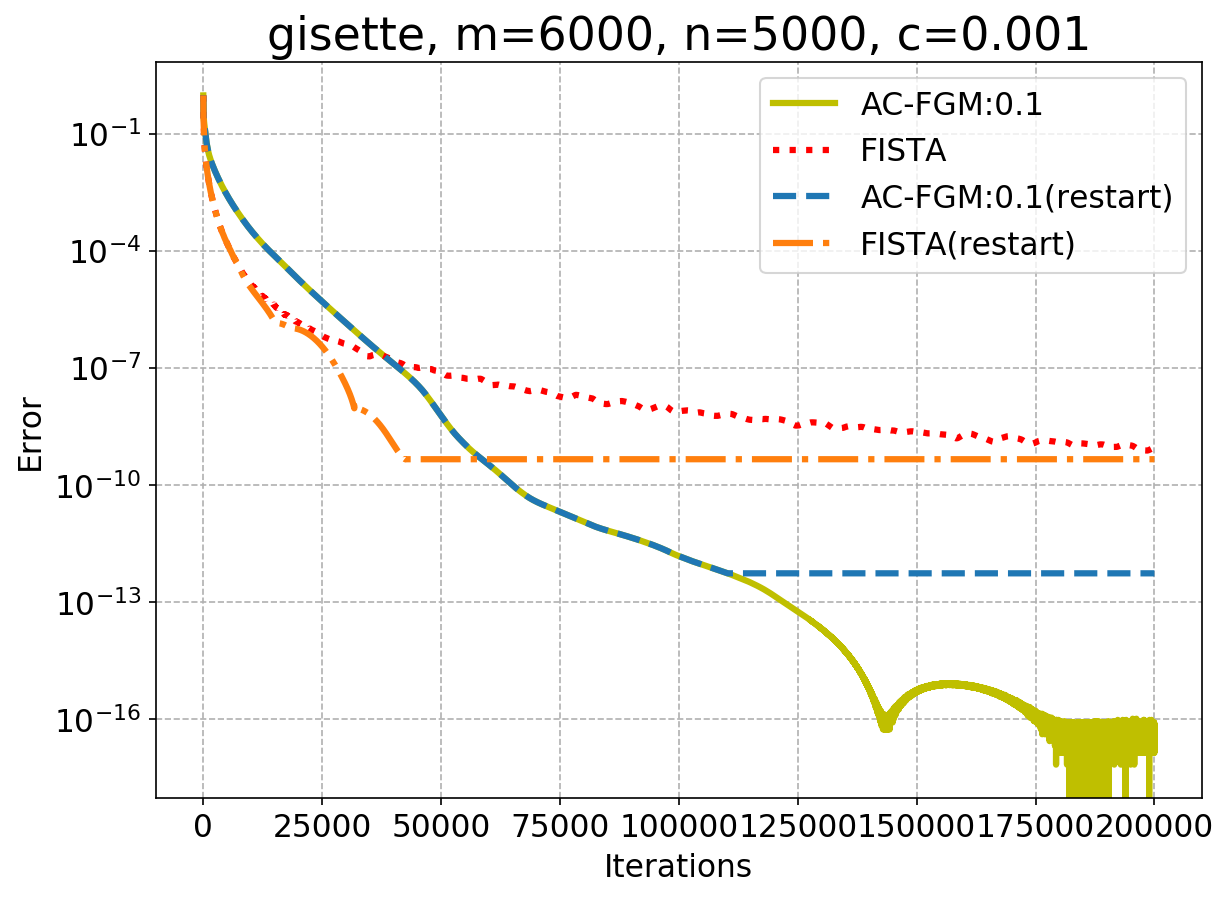

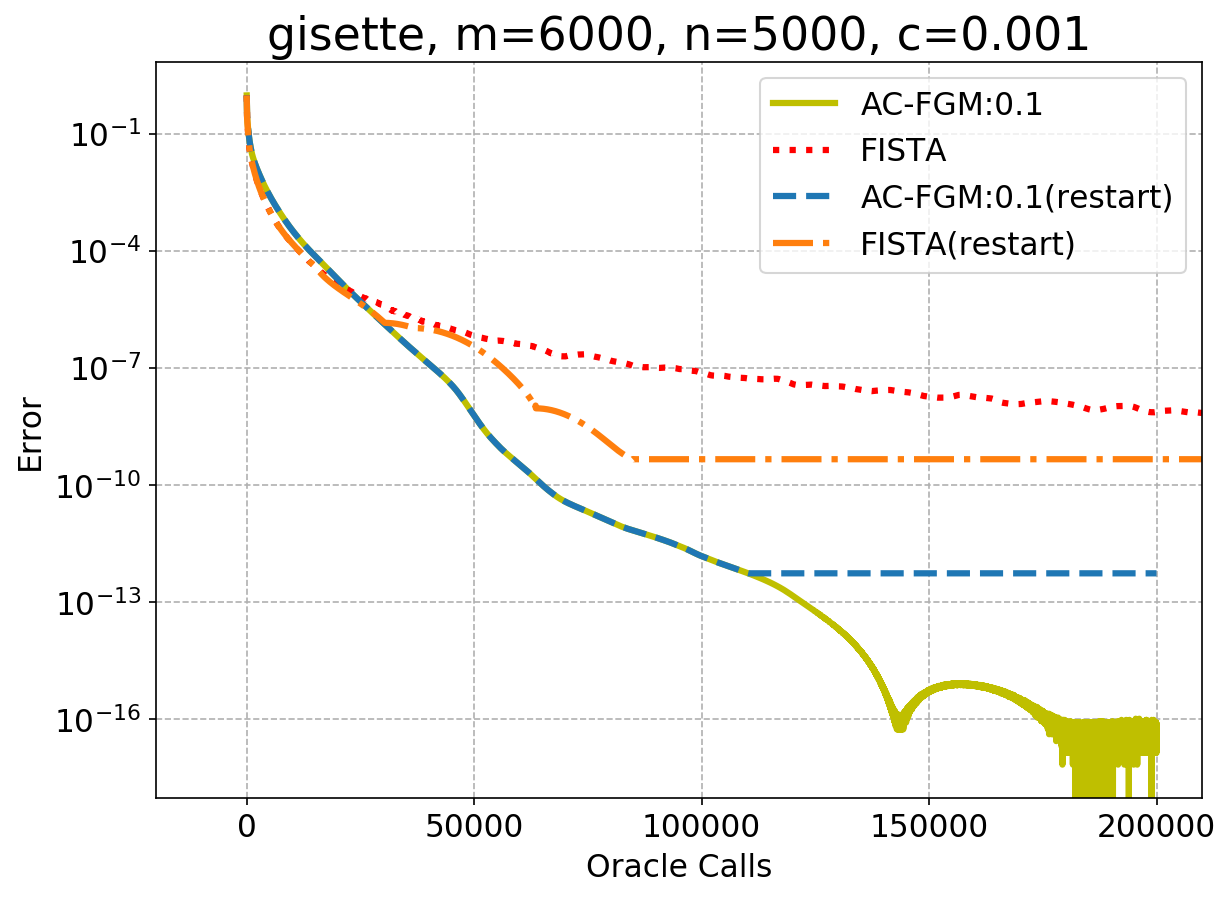

In [29]:
dataset = "gisette"
c = 0.001
k = 200000
right_lim = 210000
title = "gisette, m=6000, n=5000, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
qwl = QP_with_Lasso(A, b, c)
print("gamma: %f"%qwl.gamma)
fom = First_Order_Methods(qwl)
print("initial function value: %f"%qwl.objective(fom.x_0))
print("------------------------")
result_gisette_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('lasso_gisette_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_gisette_2, f)

# sparse logistic regression

gamma: 5.266744
initial function value: 50120.779479
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 1051.240 seconds
-----------------------------------
FISTA: k=10000
Done: 2430.275 seconds
-----------------------------------
FISTA: k=10000
Done: 2435.599 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 1115.067 seconds
-----------------------------------


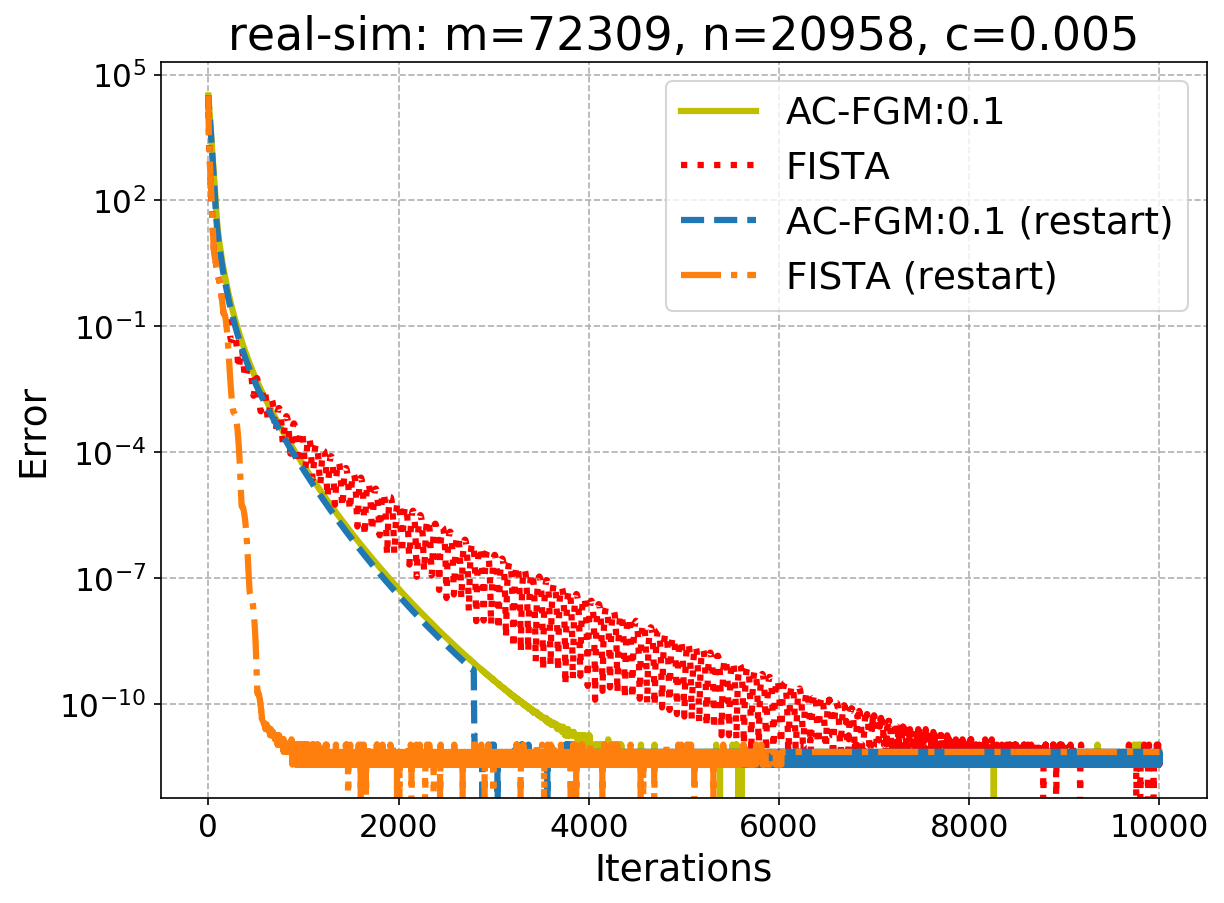

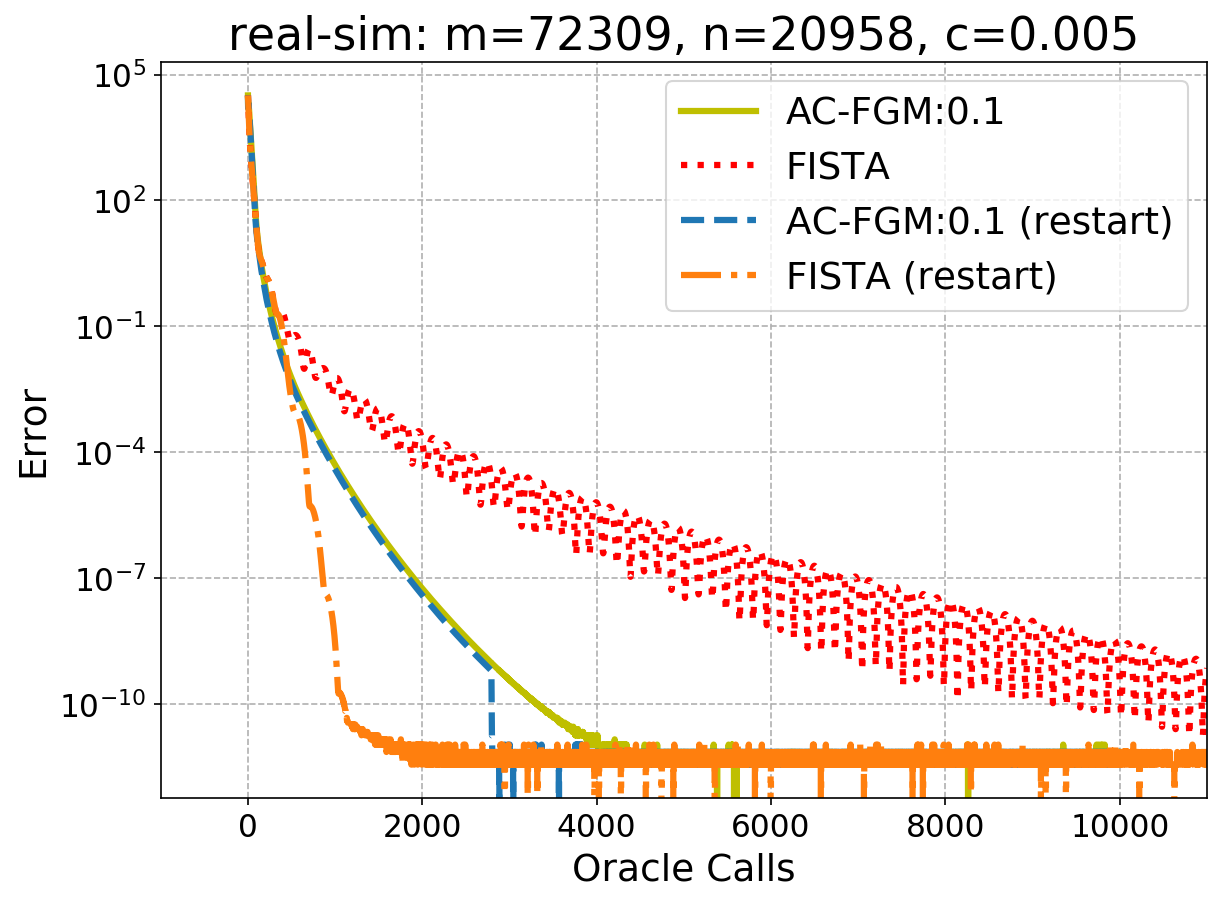

In [3]:
dataset = "real-sim"
c = 0.005
k = 10000
right_lim = 11000
title = "real-sim: m=72309, n=20958, c=0.005"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_sim_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_realsim_005_restart.pkl', 'wb') as f:  
    pickle.dump(result_real_sim_slr, f)

gamma: 1.053349
initial function value: 50120.779479
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 1943.845 seconds
-----------------------------------
FISTA: k=20000
Done: 4234.611 seconds
-----------------------------------
FISTA: k=20000
Done: 4061.934 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 1860.737 seconds
-----------------------------------


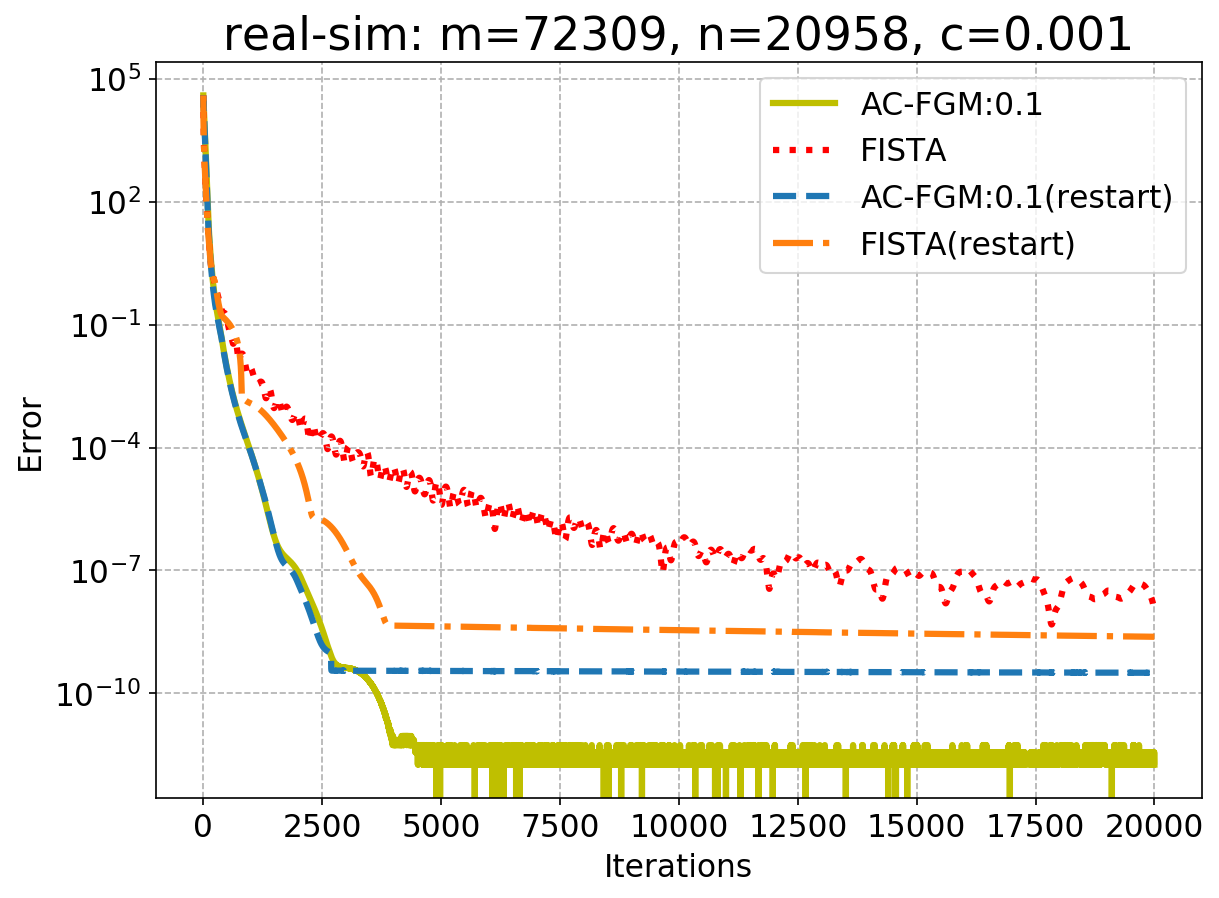

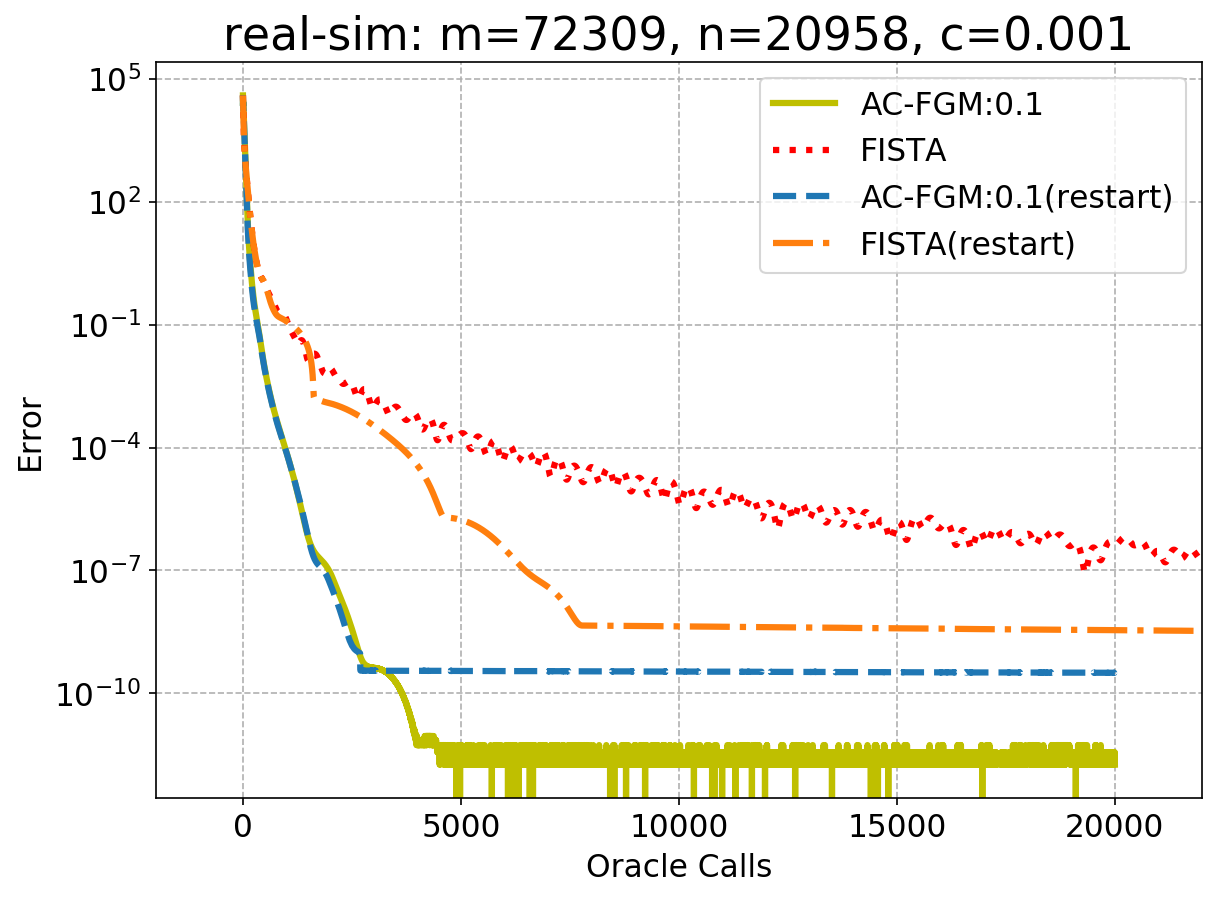

In [16]:
dataset = "real-sim"
c = 0.001
k = 20000
right_lim = 22000
title = "real-sim: m=72309, n=20958, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_sim_slr_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_realsim_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_sim_slr_2, f)

gamma: 1.321904
initial function value: 14030.685229
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 419.280 seconds
-----------------------------------
FISTA: k=10000
Done: 726.550 seconds
-----------------------------------
FISTA: k=10000
Done: 721.919 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 369.356 seconds
-----------------------------------


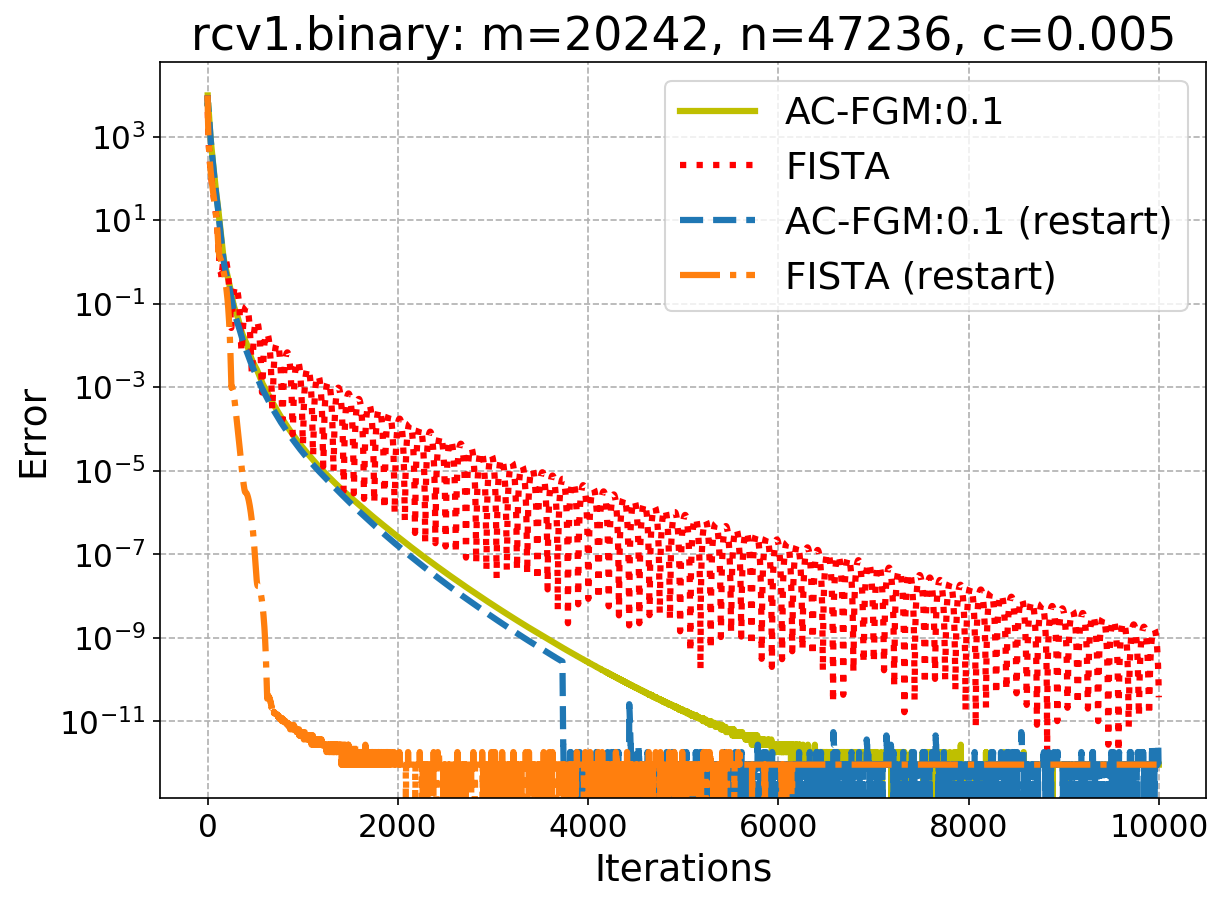

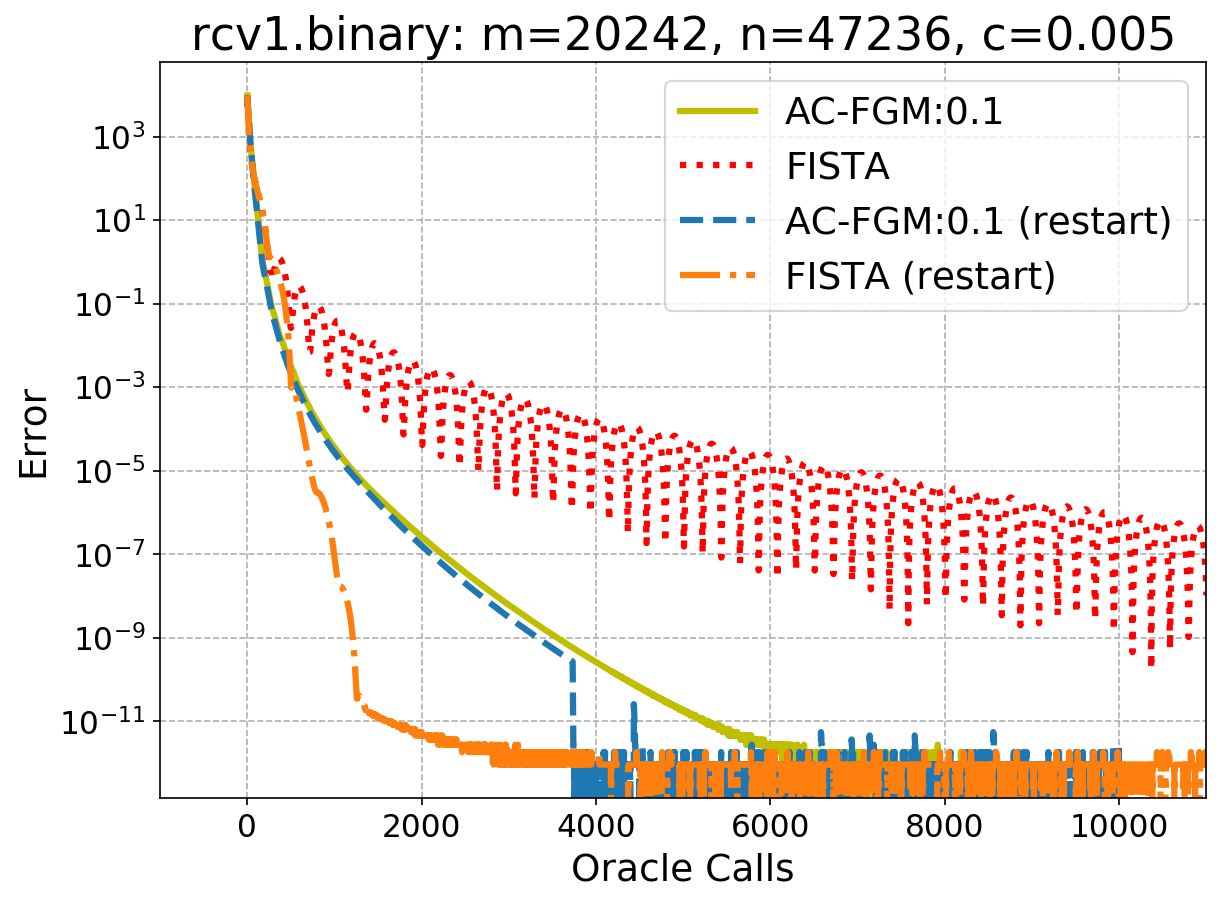

In [4]:
dataset = "rcv1.binary"
c = 0.005
k = 10000
right_lim = 11000
title = "rcv1.binary: m=20242, n=47236, c=0.005"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_rcv_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_rcv_005_restart.pkl', 'wb') as f:  
    pickle.dump(result_real_rcv_slr, f)

gamma: 0.264381
initial function value: 14030.685229
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 785.220 seconds
-----------------------------------
FISTA: k=20000
Done: 1535.349 seconds
-----------------------------------
FISTA: k=20000
Done: 1543.746 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 793.634 seconds
-----------------------------------


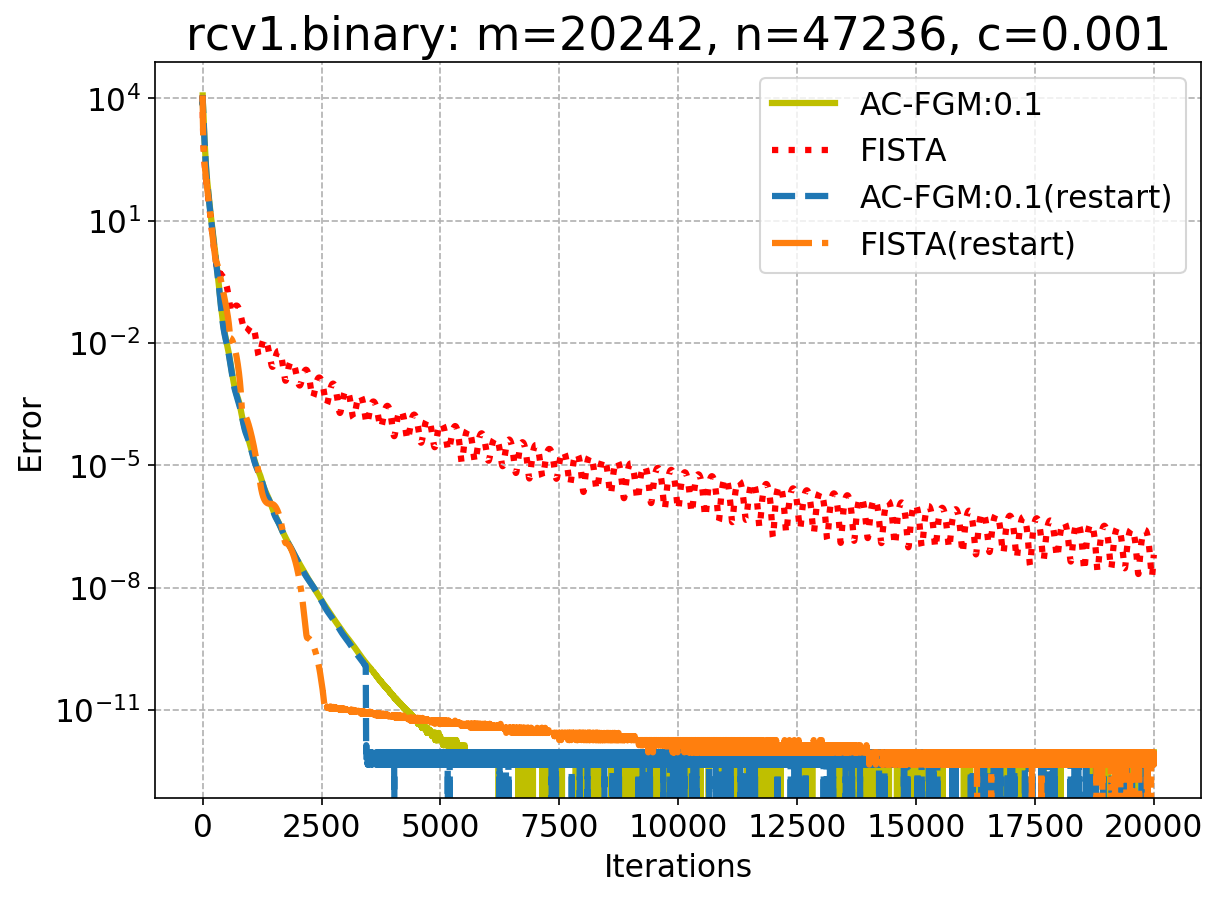

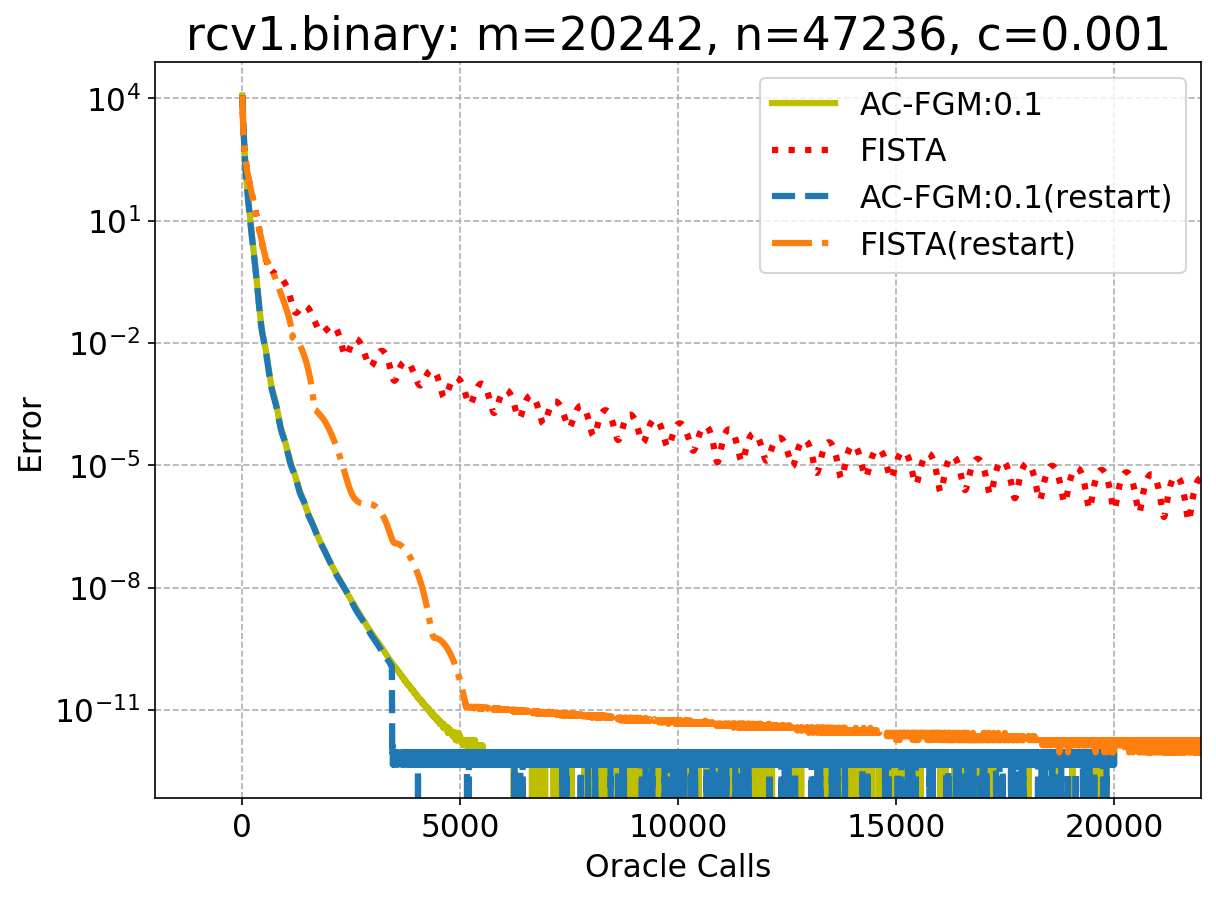

In [ ]:
dataset = "rcv1.binary"
c = 0.001
k = 20000
right_lim = 22000
title = "rcv1.binary: m=20242, n=47236, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_rcv_slr_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_rcv_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_rcv_slr_2, f)

gamma: 18.670170
initial function value: 4158.883083
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 618.811 seconds
-----------------------------------
FISTA: k=10000
Done: 1065.138 seconds
-----------------------------------
FISTA: k=10000
Done: 1082.176 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 598.961 seconds
-----------------------------------


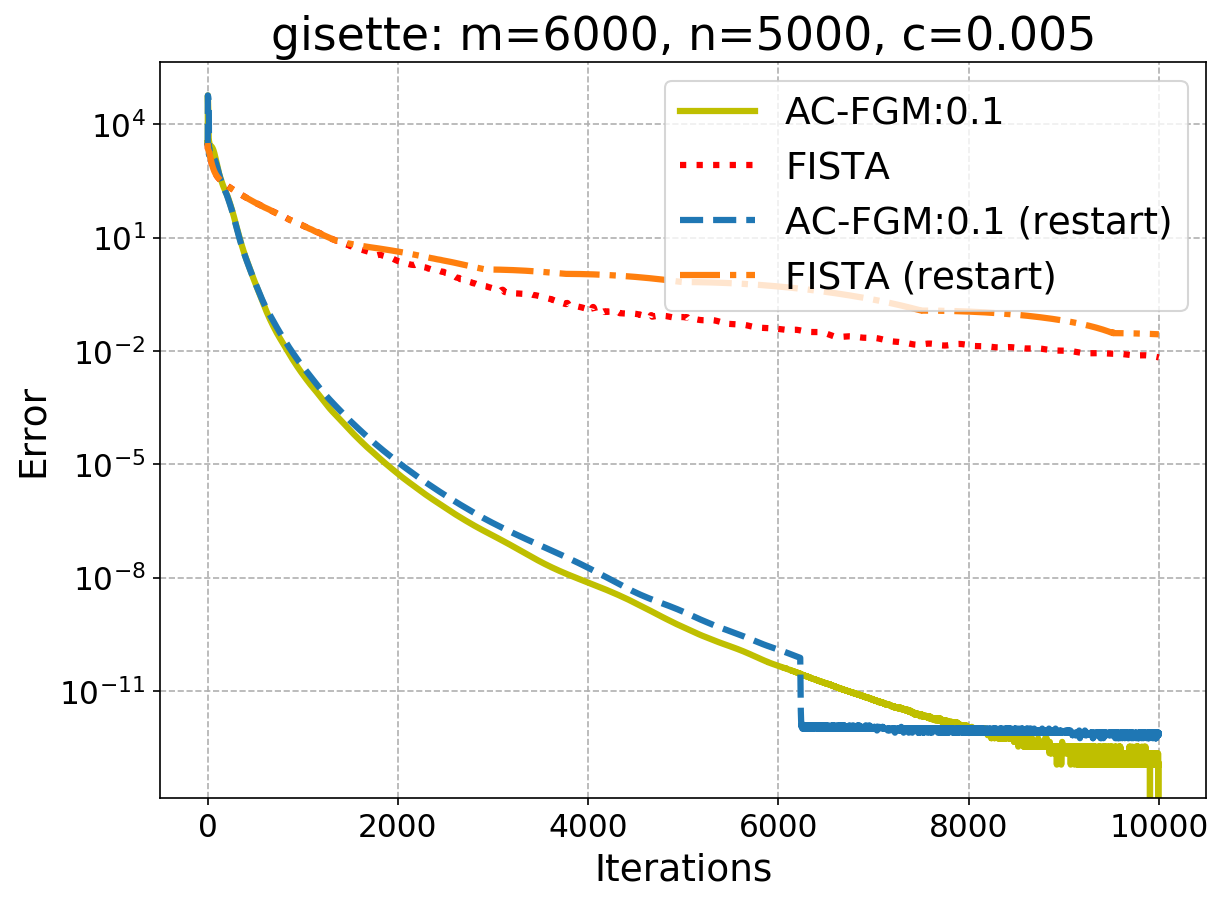

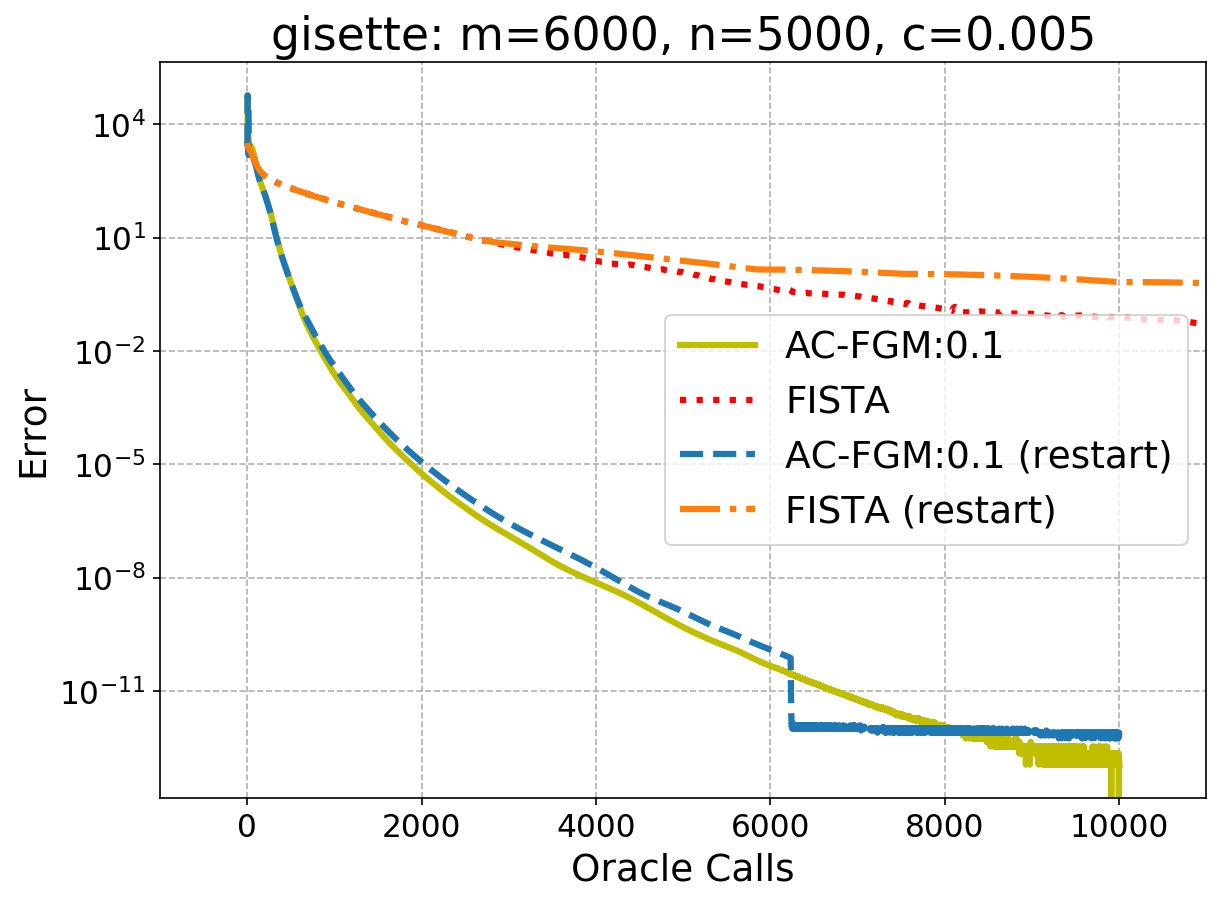

In [5]:
dataset = "gisette"
c = 0.005
k = 10000
right_lim = 11000
title = "gisette: m=6000, n=5000, c=0.005"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_gisette_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_gisette_005_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_gisette_slr, f)

gamma: 3.734034
initial function value: 4158.883083
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 1168.627 seconds
-----------------------------------
FISTA: k=20000
Done: 2122.737 seconds
-----------------------------------
FISTA: k=20000
Done: 2085.879 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 1179.351 seconds
-----------------------------------


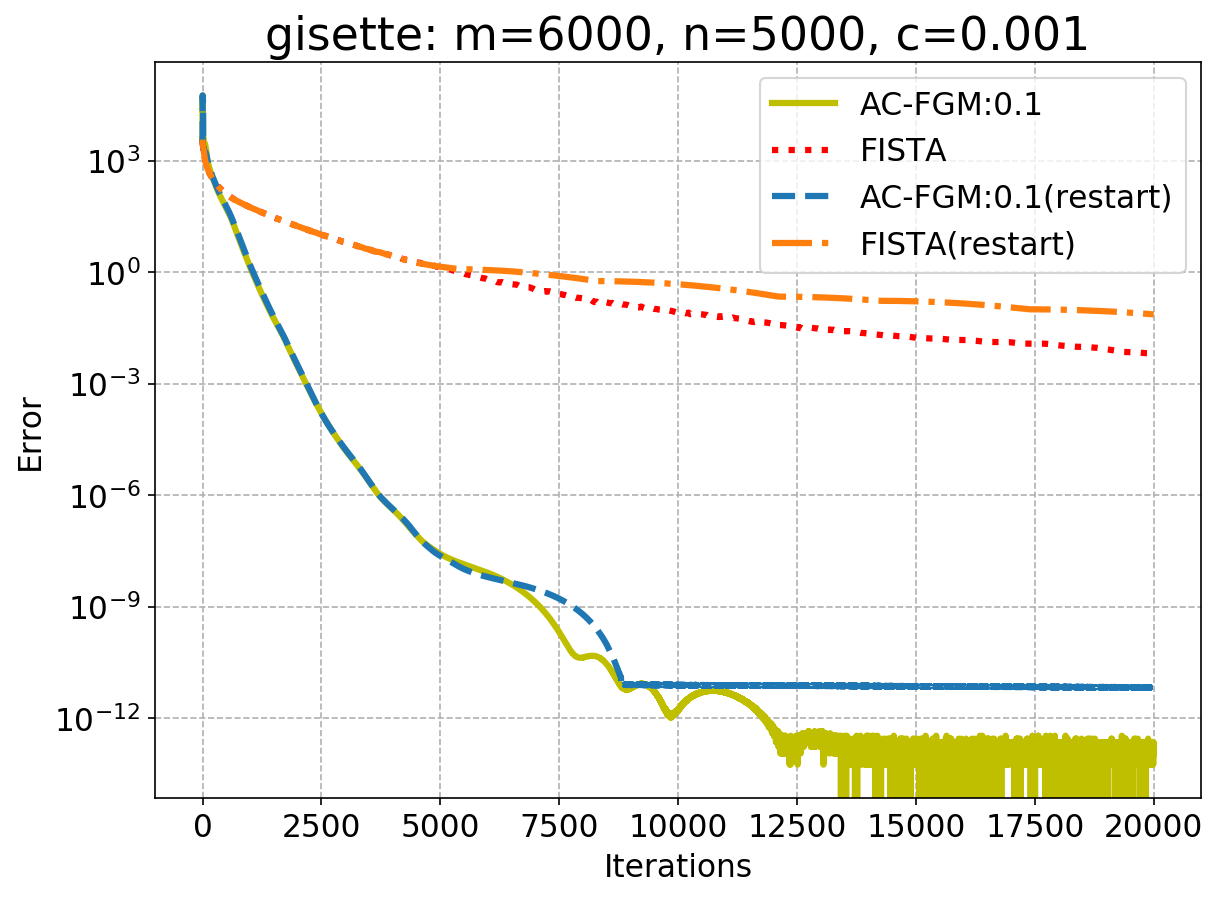

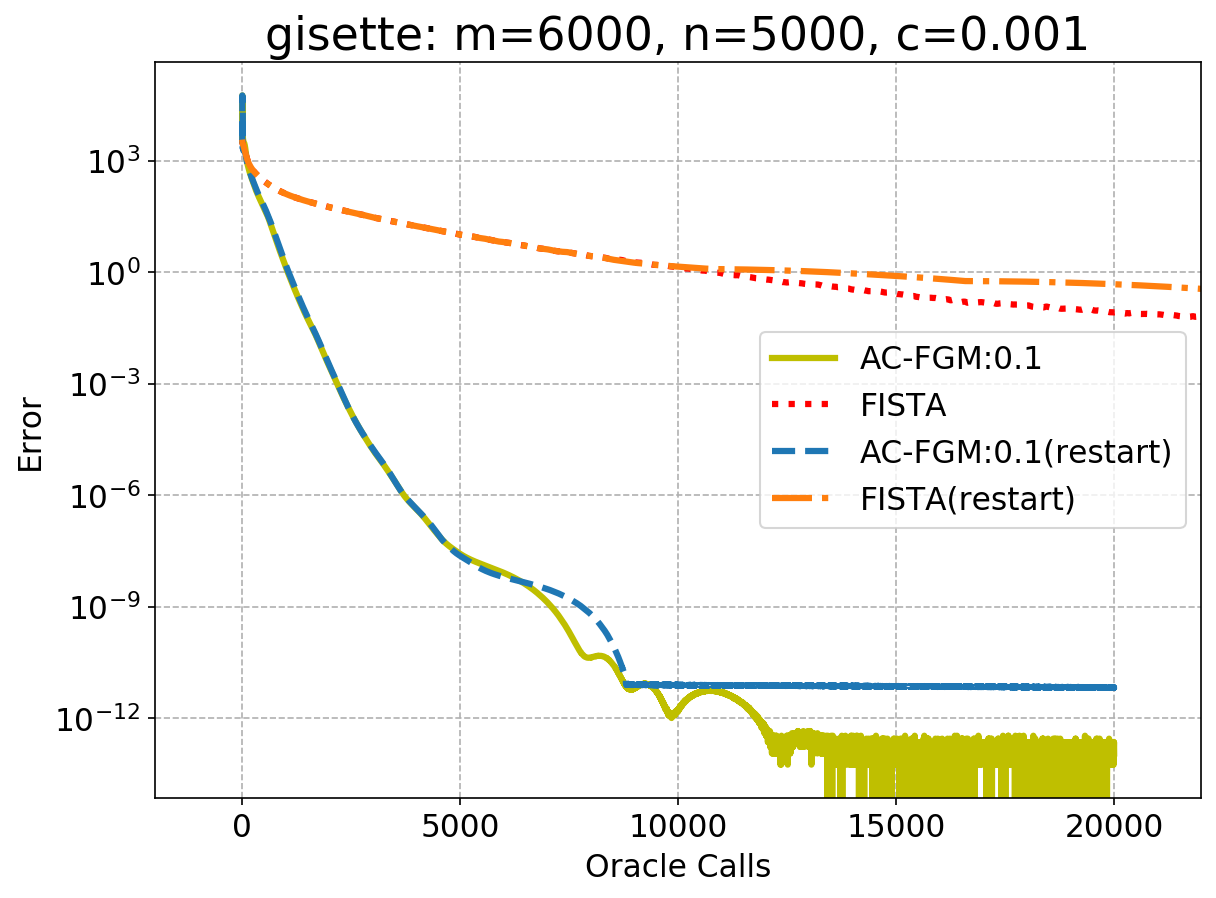

In [20]:
dataset = "gisette"
c = 0.001
k = 20000
right_lim = 22000
title = "gisette: m=6000, n=5000, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_gisette_slr_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_gisette_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_gisette_slr_2, f)

gamma: 87.605000
initial function value: 22569.565346
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 24.603 seconds
-----------------------------------
FISTA: k=10000
Done: 60.727 seconds
-----------------------------------
FISTA: k=10000
Done: 59.323 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 24.007 seconds
-----------------------------------


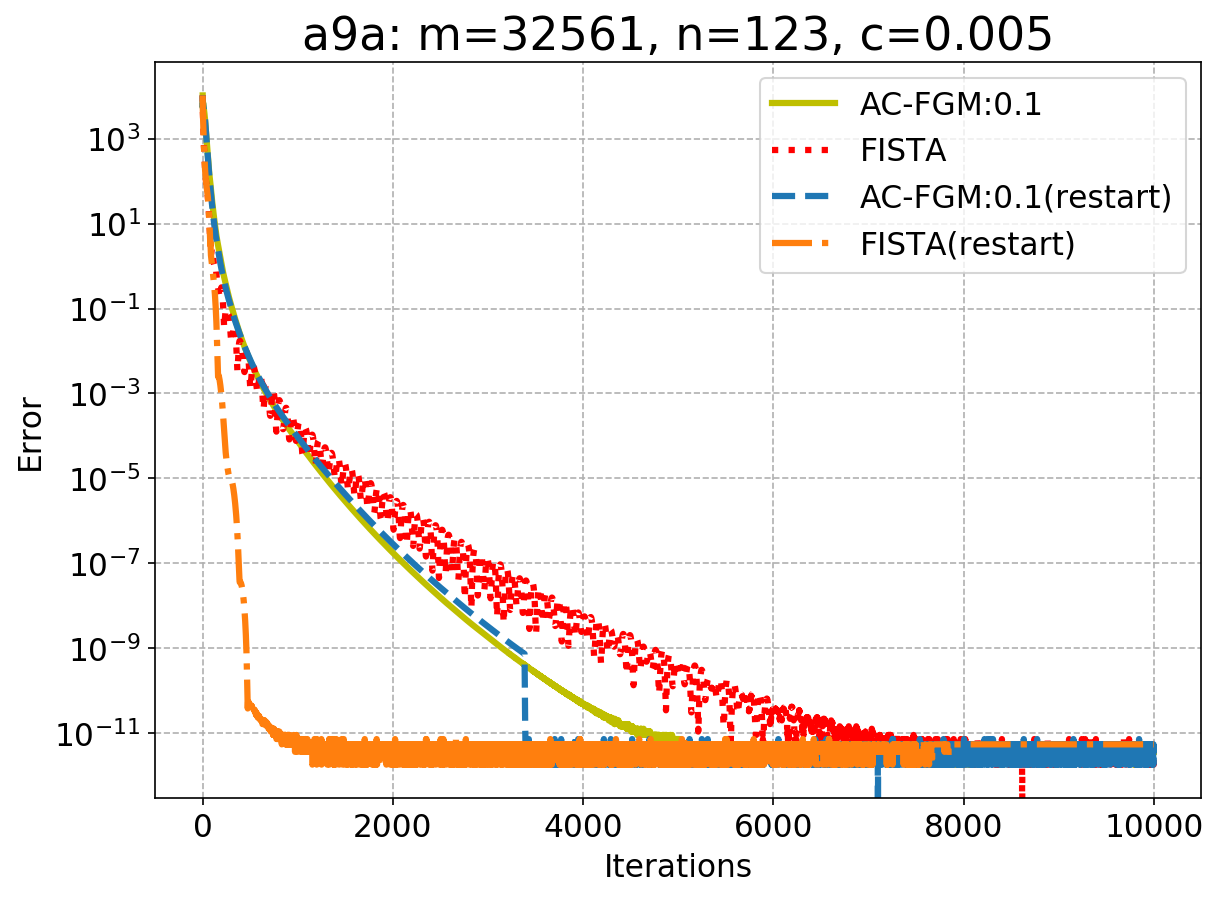

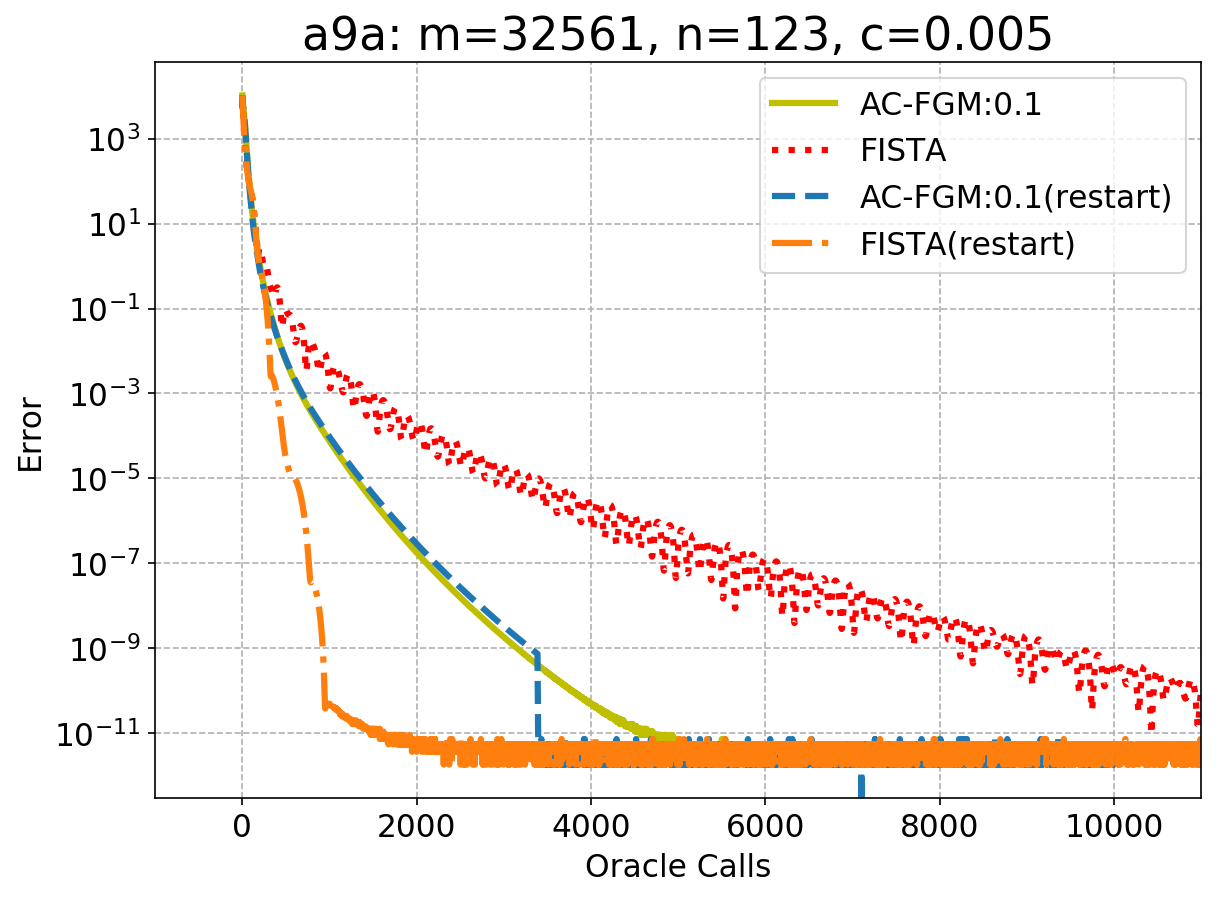

In [21]:
dataset = "a9a"
c = 0.005
k = 10000
right_lim = 11000
title = "a9a: m=32561, n=123, c=0.005"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_a9a_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_a9a_005_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_a9a_slr, f)

gamma: 17.521000
initial function value: 22569.565346
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 48.137 seconds
-----------------------------------
FISTA: k=20000
Done: 118.410 seconds
-----------------------------------
FISTA: k=20000
Done: 118.369 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 48.096 seconds
-----------------------------------


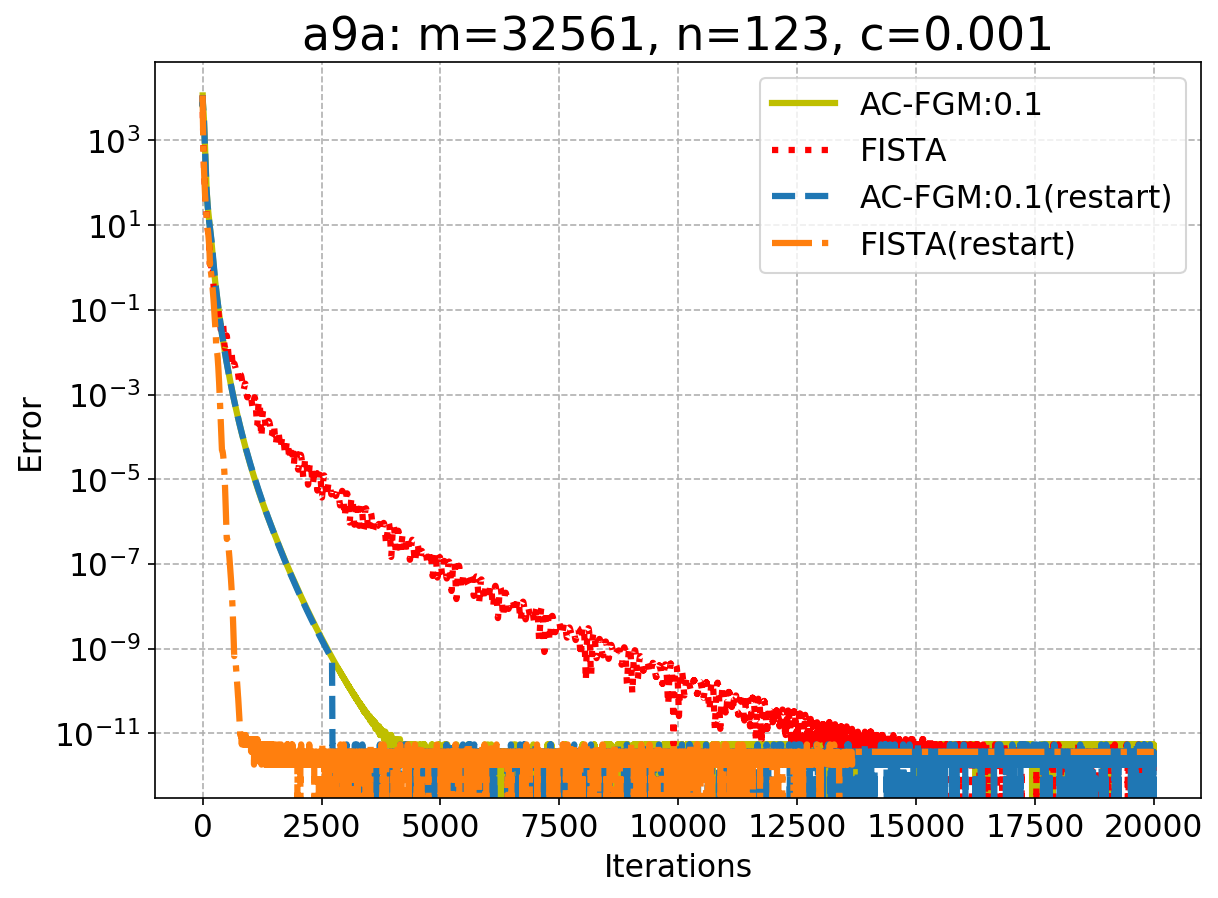

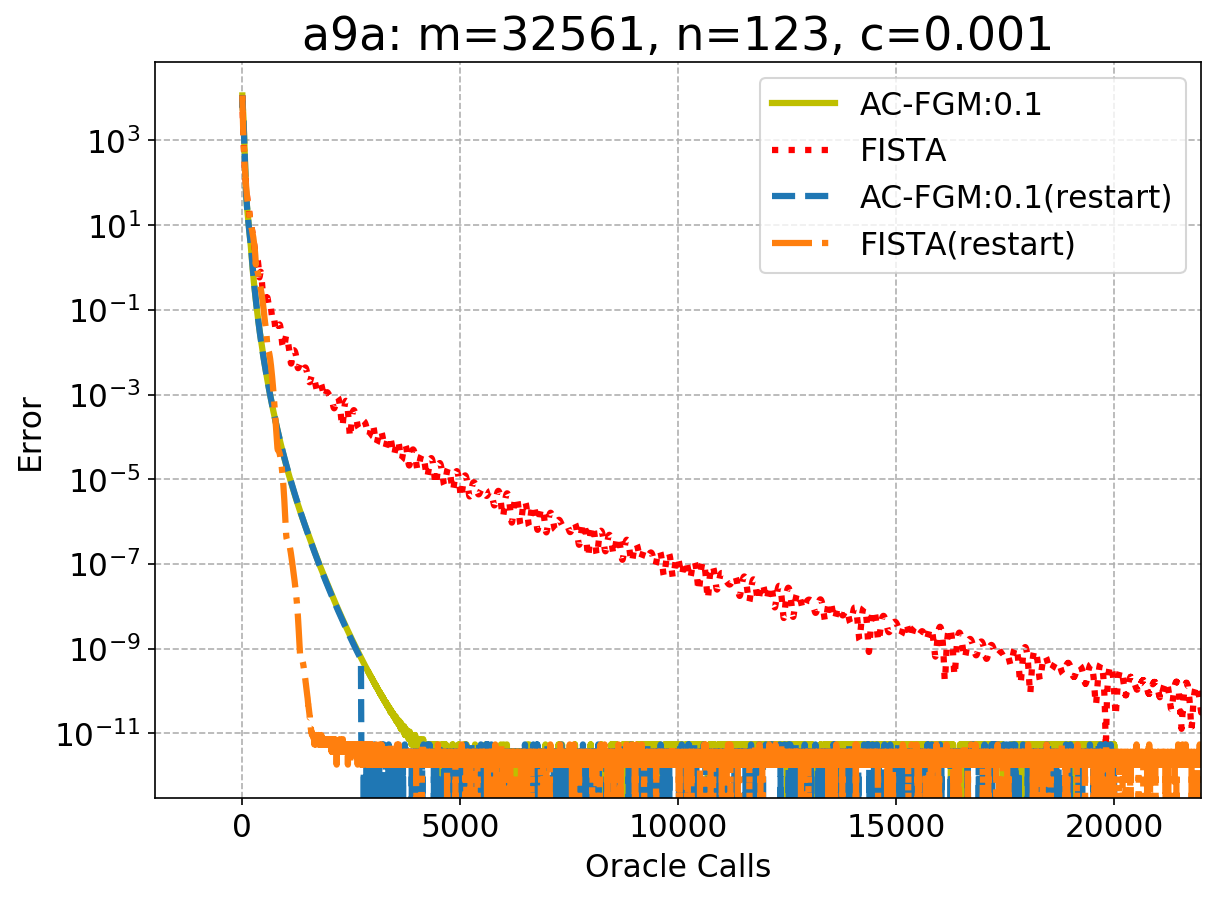

In [22]:
dataset = "a9a"
c = 0.001
k = 20000
right_lim = 22000
title = "a9a: m=32561, n=123, c=0.001"

print("========================")
A, b = fetch_libsvm(dataset)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_a9a_slr_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_a9a_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_a9a_slr_2, f)

splice: m=1000, n=60, c=0.001
gamma: 0.608000
initial function value: 693.147181
------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 4.861 seconds
-----------------------------------
FISTA: k=5000
Done: 7.713 seconds
-----------------------------------
FISTA: k=5000
Done: 9.971 seconds
-----------------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 7.515 seconds
-----------------------------------


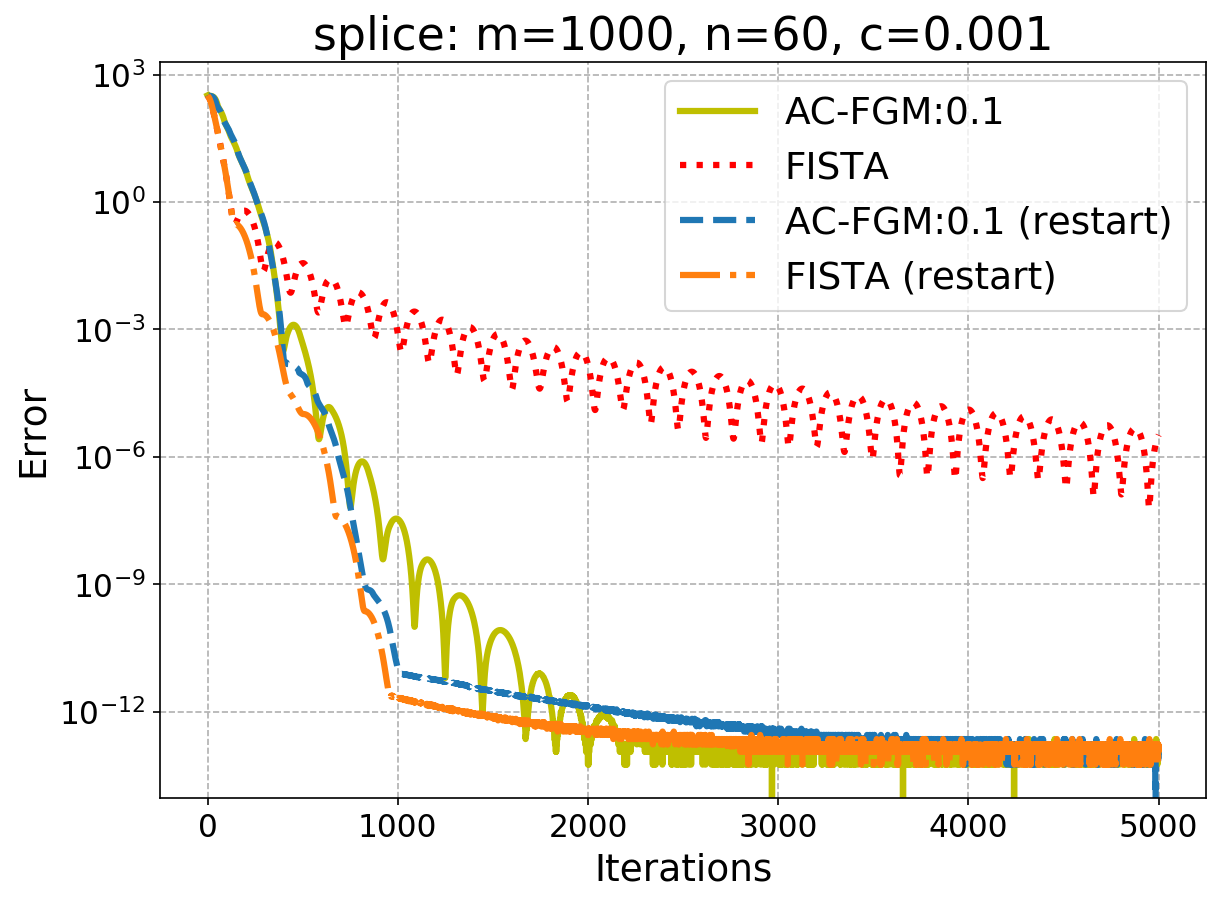

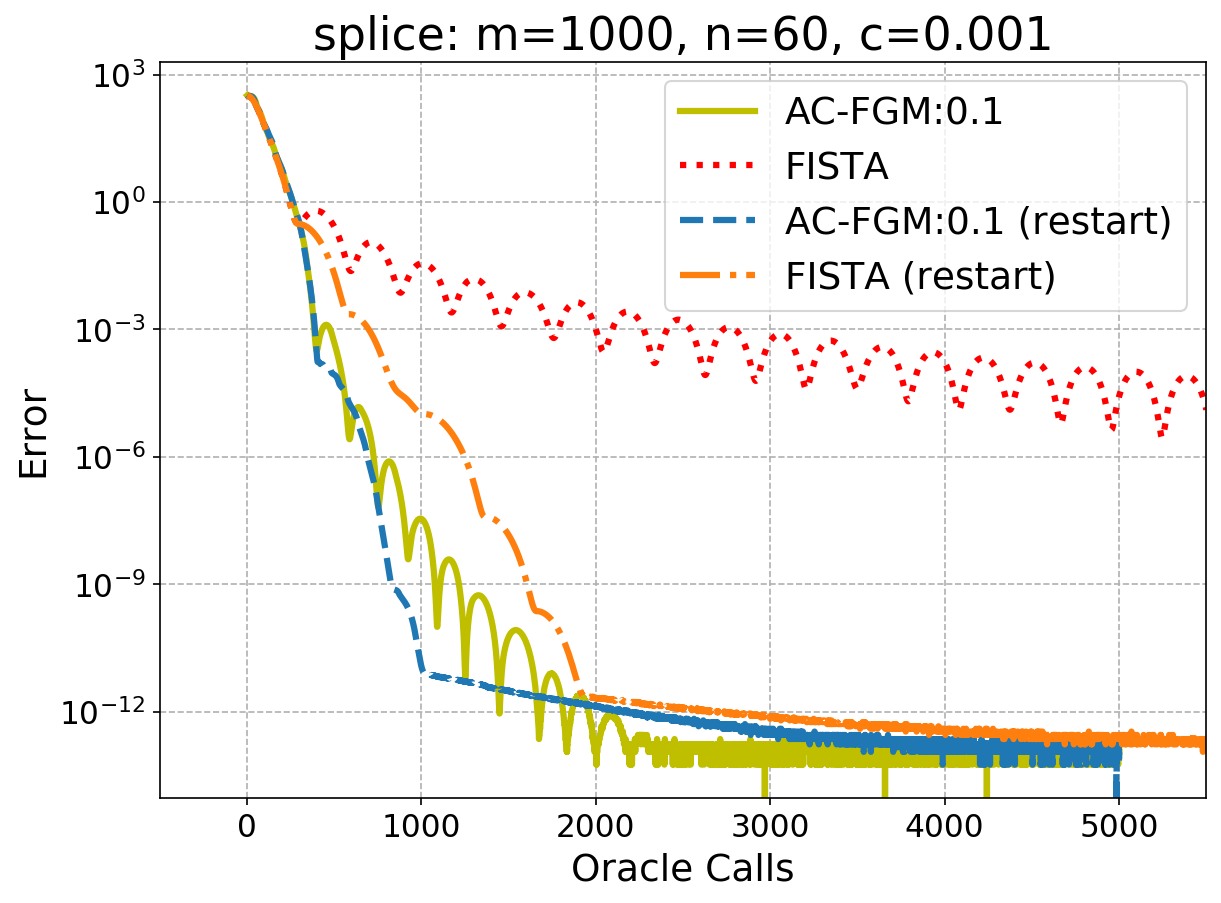

In [6]:
dataset = "splice"
c = 0.001
k = 5000
right_lim = 5500

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

splice: m=1000, n=60, c=0.005
gamma: 3.040000
initial function value: 693.147181
------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 6.751 seconds
-----------------------------------
FISTA: k=5000
Done: 10.897 seconds
-----------------------------------
FISTA: k=5000
Done: 9.893 seconds
-----------------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 7.001 seconds
-----------------------------------


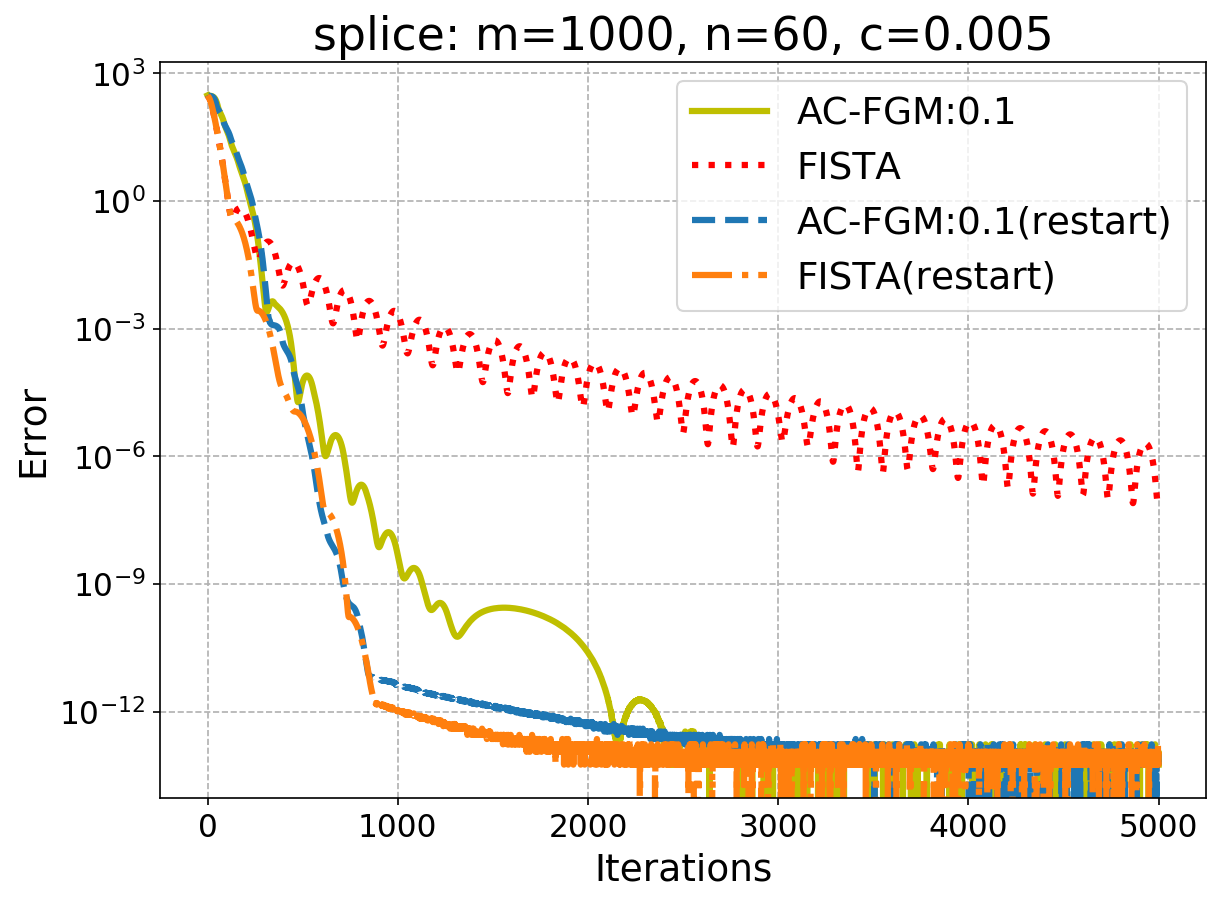

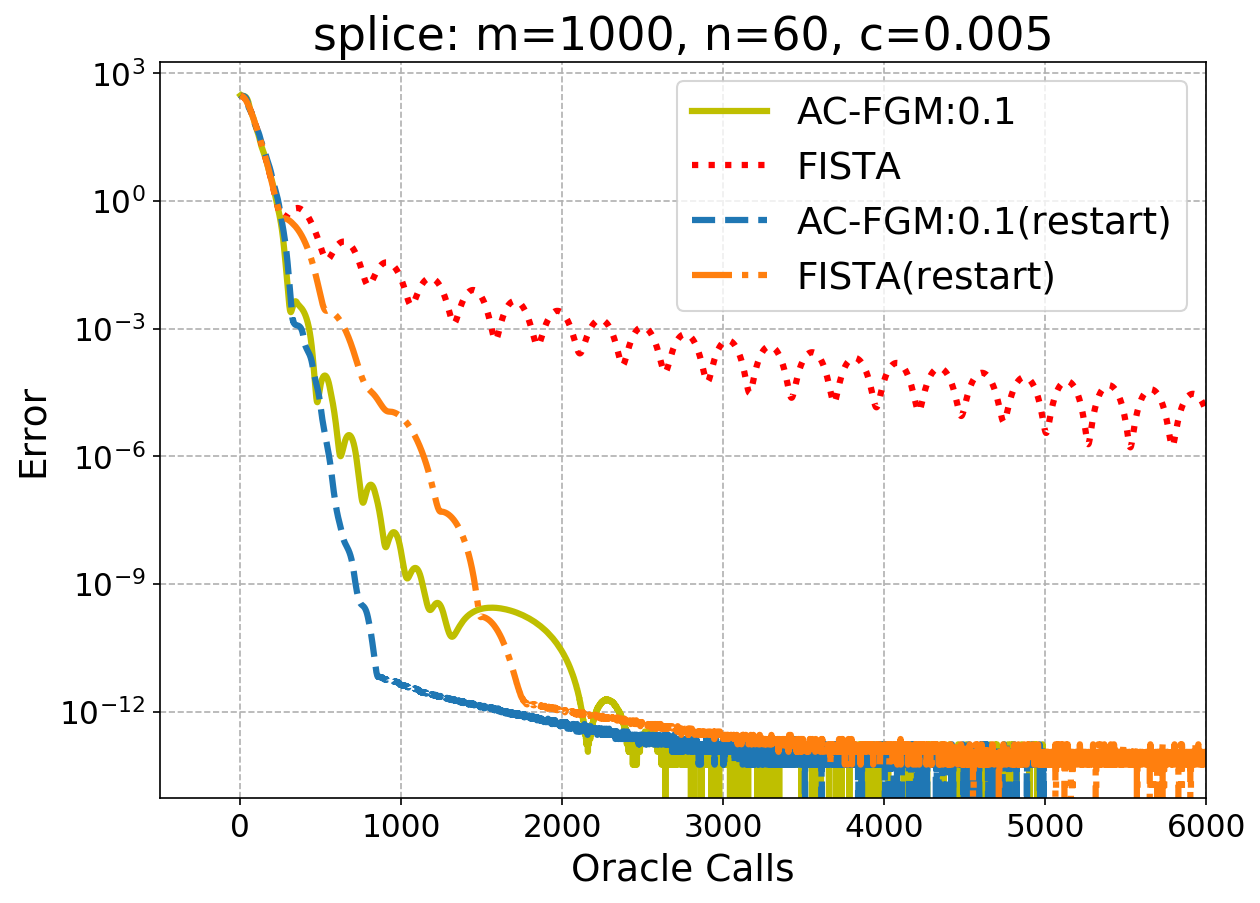

In [3]:
dataset = "splice"
c = 0.005
k = 5000
right_lim = 6000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

splice_test: m=2175, n=60, c=0.001
gamma: 1.386000
initial function value: 1507.595118
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 15.208 seconds
-----------------------------------
FISTA: k=10000
Done: 23.623 seconds
-----------------------------------
FISTA: k=10000
Done: 24.962 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 15.696 seconds
-----------------------------------


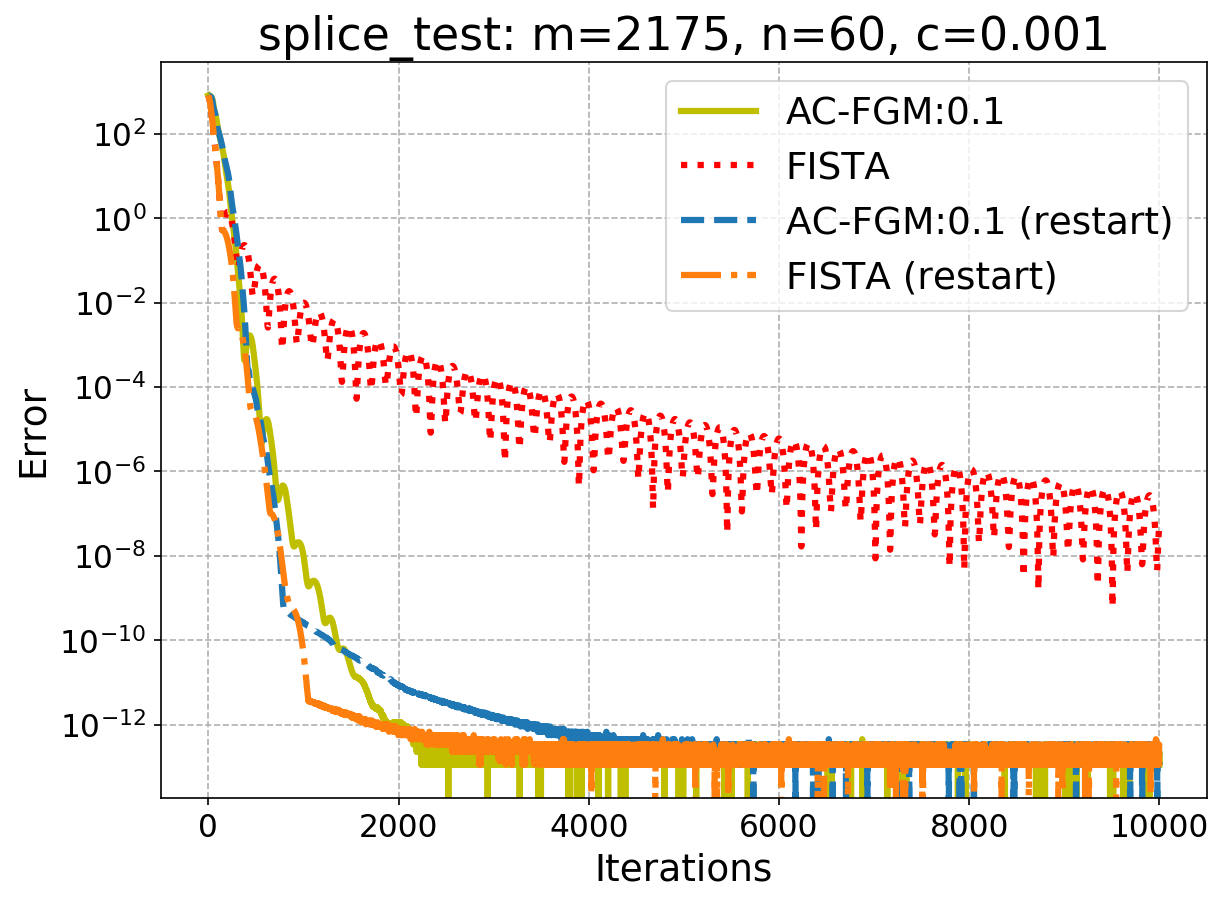

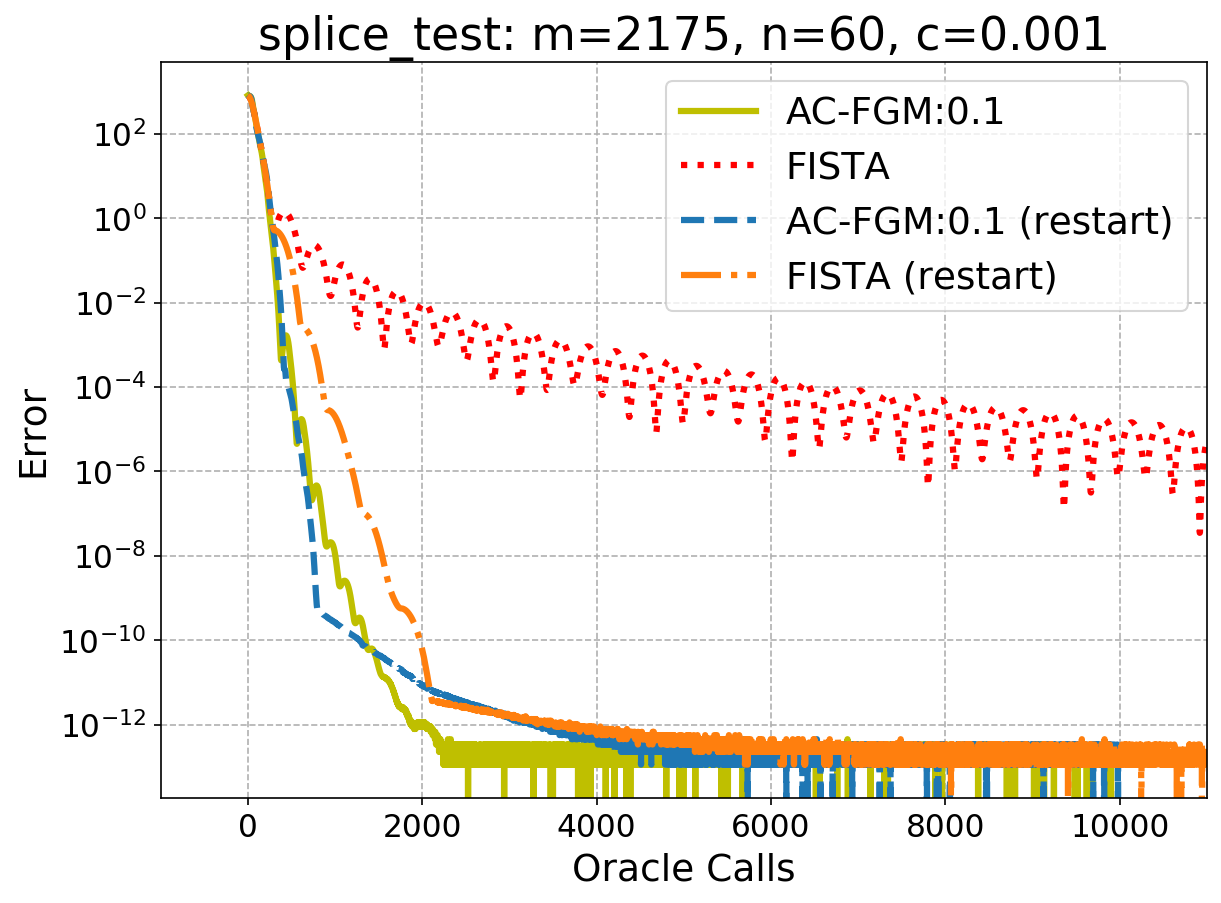

In [7]:
dataset = "splice_test"
c = 0.001
k = 10000
right_lim = 11000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

splice_test: m=2175, n=60, c=0.005
gamma: 6.930000
initial function value: 1507.595118
------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 6.574 seconds
-----------------------------------
FISTA: k=5000
Done: 12.264 seconds
-----------------------------------
FISTA: k=5000
Done: 12.542 seconds
-----------------------------------
AC-FGM: k=5000, alpha=0.100, beta=0.184
Done: 7.608 seconds
-----------------------------------


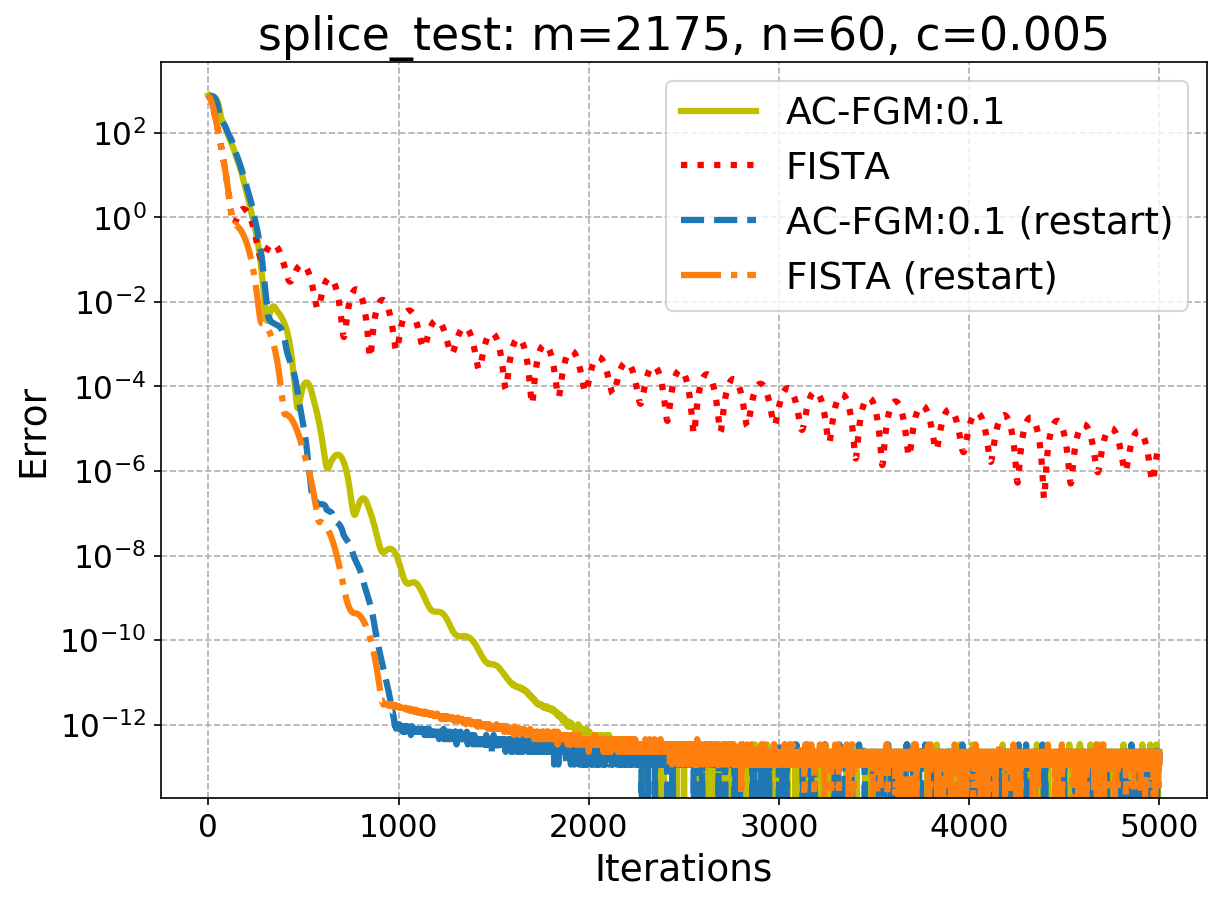

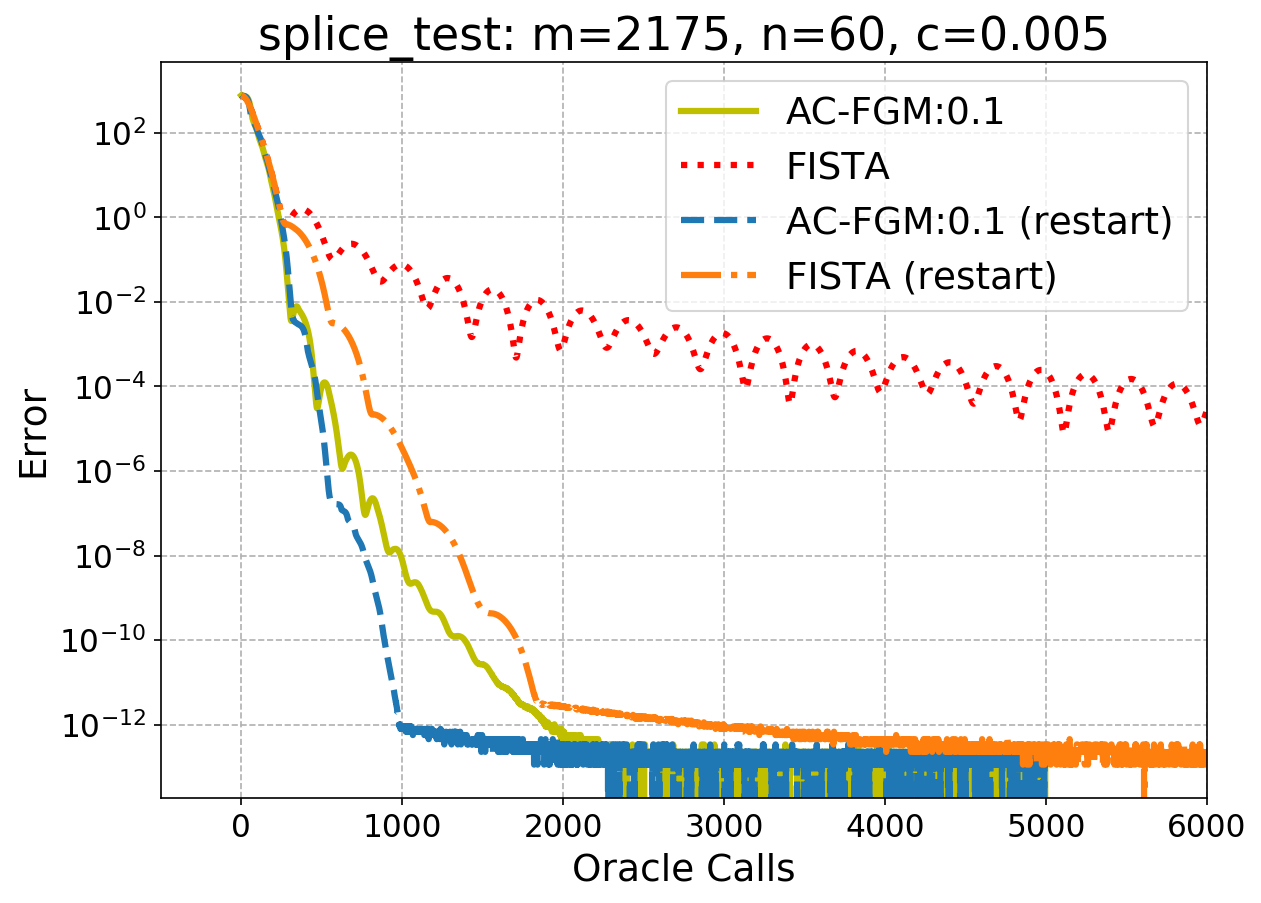

In [8]:
dataset = "splice_test"
c = 0.005
k = 5000
right_lim = 6000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

ionosphere: m=351, n=34, c=0.001
gamma: 0.175000
initial function value: 243.294660
------------------------
AC-FGM: k=4000, alpha=0.100, beta=0.184
Done: 3.706 seconds
-----------------------------------
FISTA: k=4000
Done: 5.329 seconds
-----------------------------------
FISTA: k=4000
Done: 5.790 seconds
-----------------------------------
AC-FGM: k=4000, alpha=0.100, beta=0.184
Done: 4.181 seconds
-----------------------------------


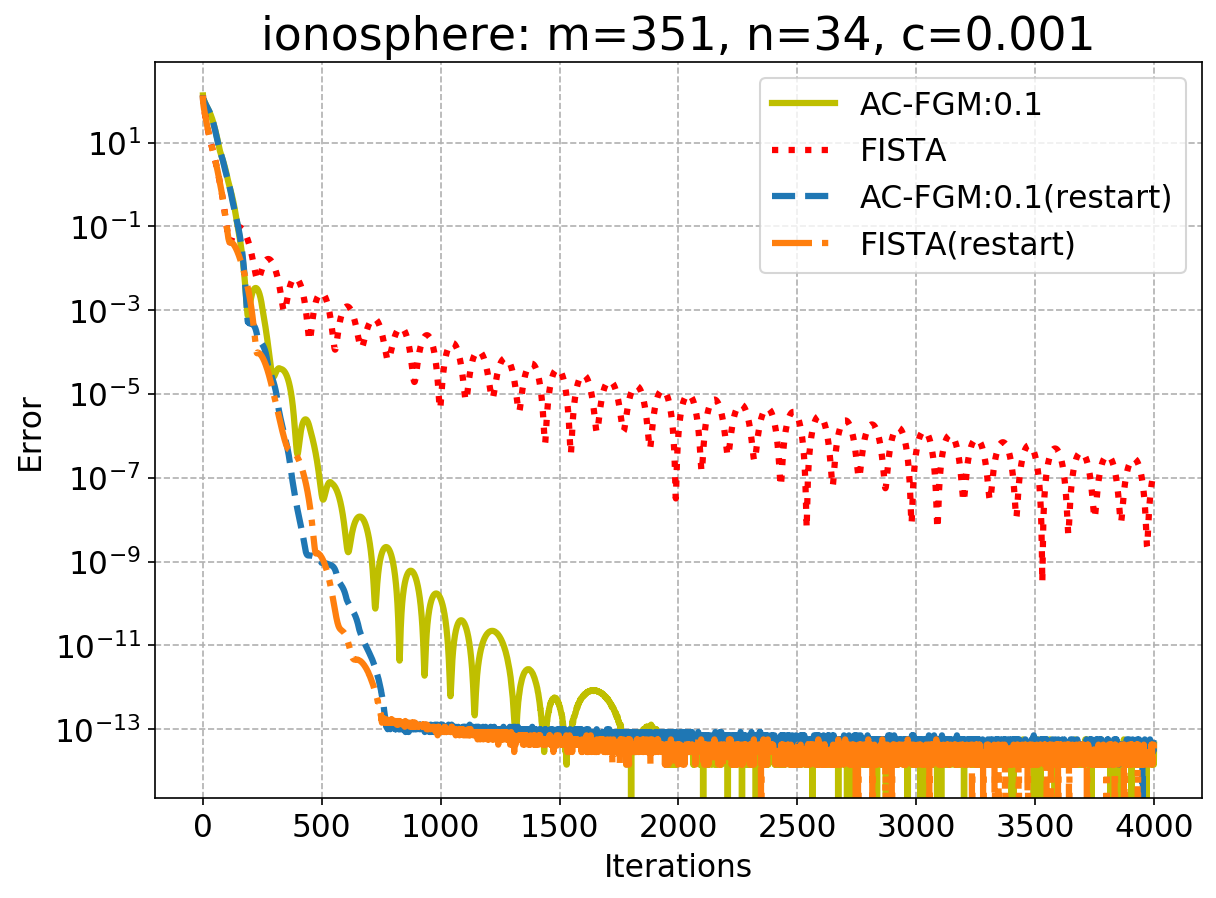

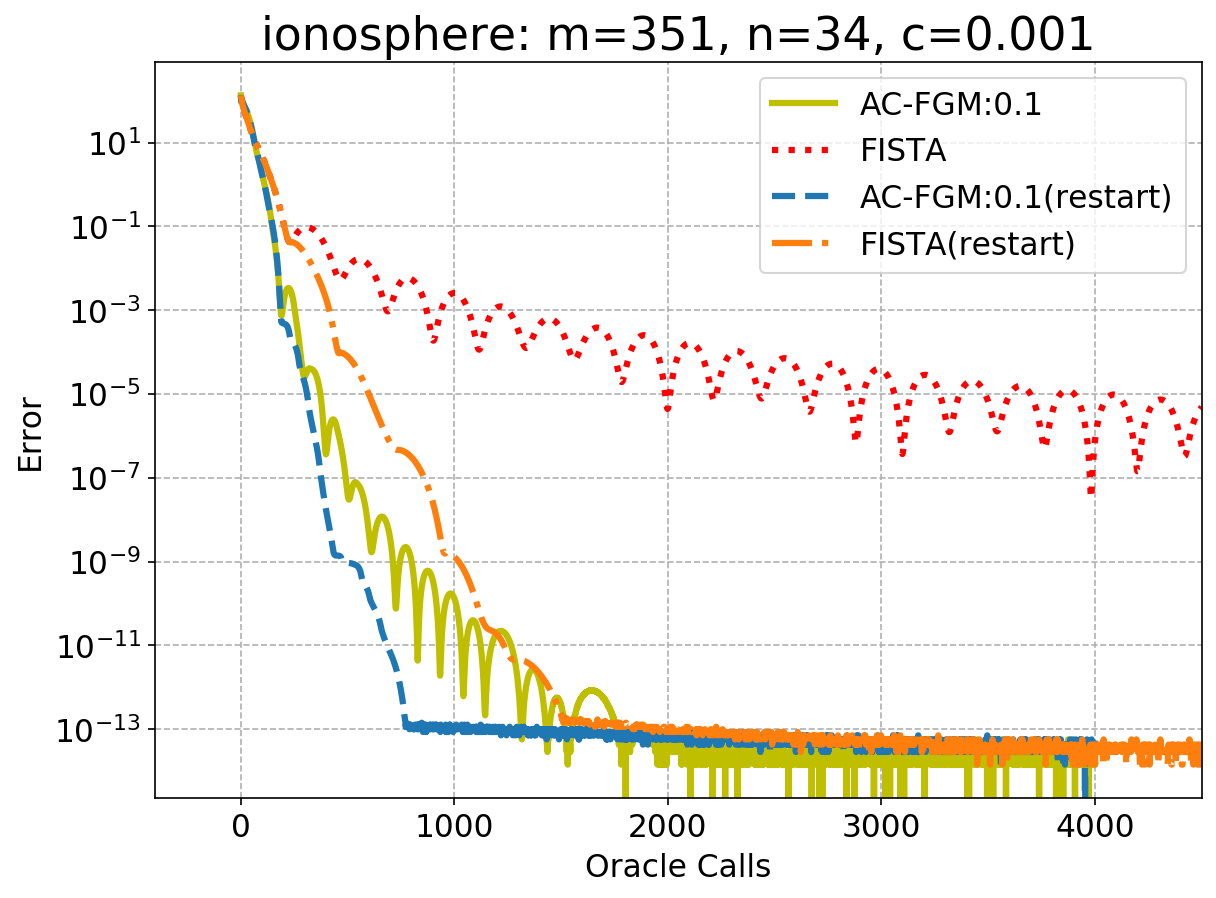

In [24]:
dataset = "ionosphere"
c = 0.001
k = 4000
right_lim = 4500

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

ionosphere: m=351, n=34, c=0.005
gamma: 0.875000
initial function value: 243.294660
------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 9.018 seconds
-----------------------------------
FISTA: k=10000
Done: 13.103 seconds
-----------------------------------
FISTA: k=10000
Done: 13.064 seconds
-----------------------------------
AC-FGM: k=10000, alpha=0.100, beta=0.184
Done: 9.339 seconds
-----------------------------------


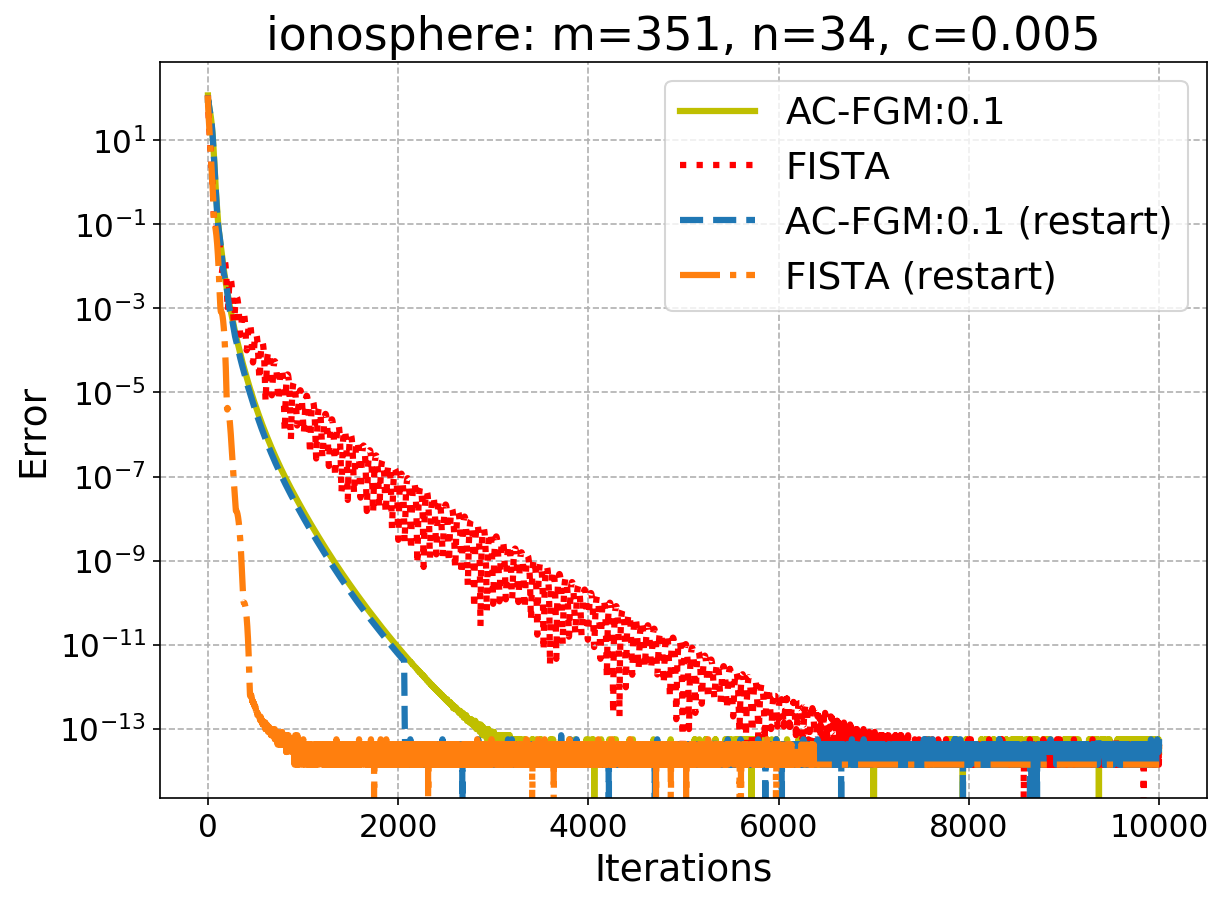

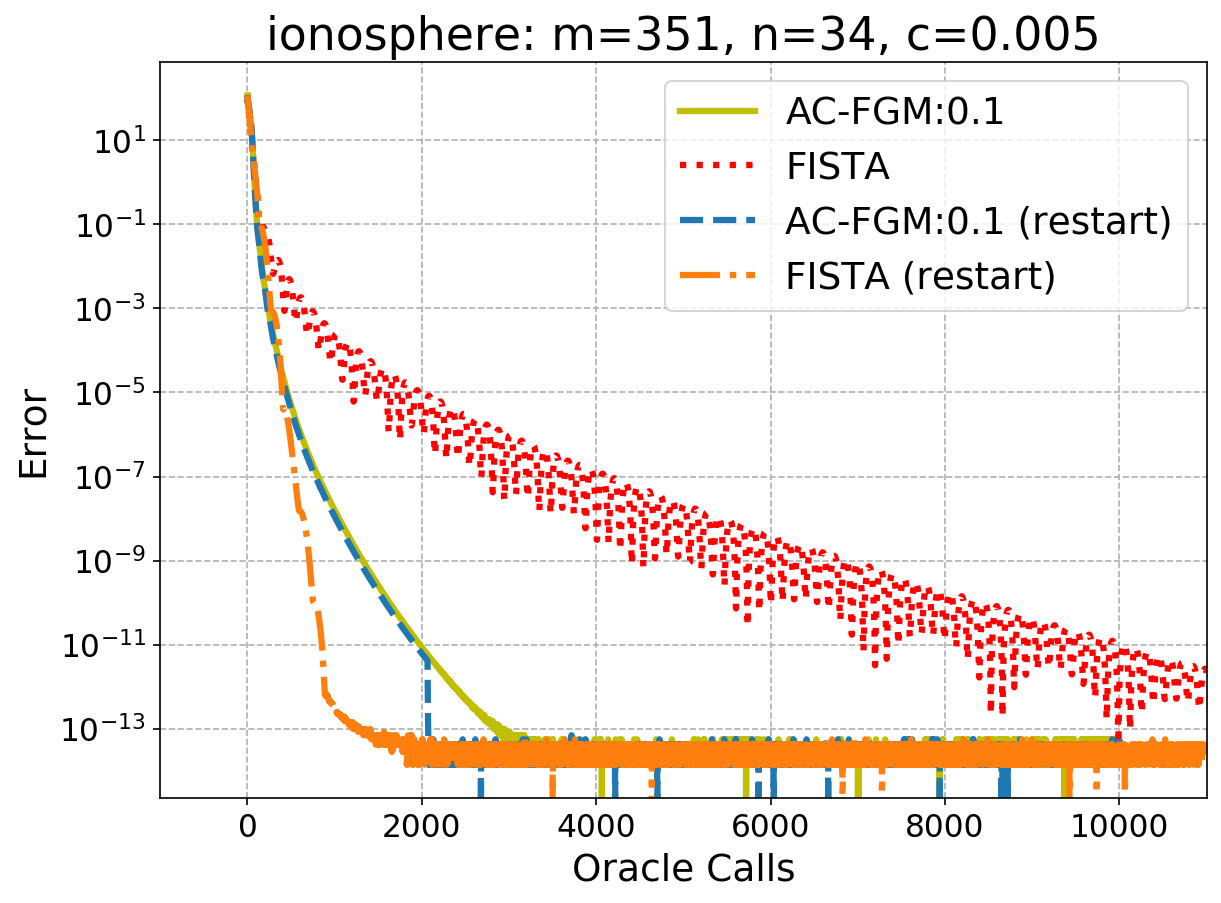

In [9]:
dataset = "ionosphere"
c = 0.005
k = 10000
right_lim = 11000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

gamma: 54.306363
initial function value: 402726.829671
------------------------
AC-FGM: k=30000, alpha=0.100, beta=0.184
Done: 1180.625 seconds
-----------------------------------
FISTA: k=30000
Done: 2977.613 seconds
-----------------------------------
FISTA: k=30000
Done: 2983.940 seconds
-----------------------------------
AC-FGM: k=30000, alpha=0.100, beta=0.184
Done: 1180.206 seconds
-----------------------------------


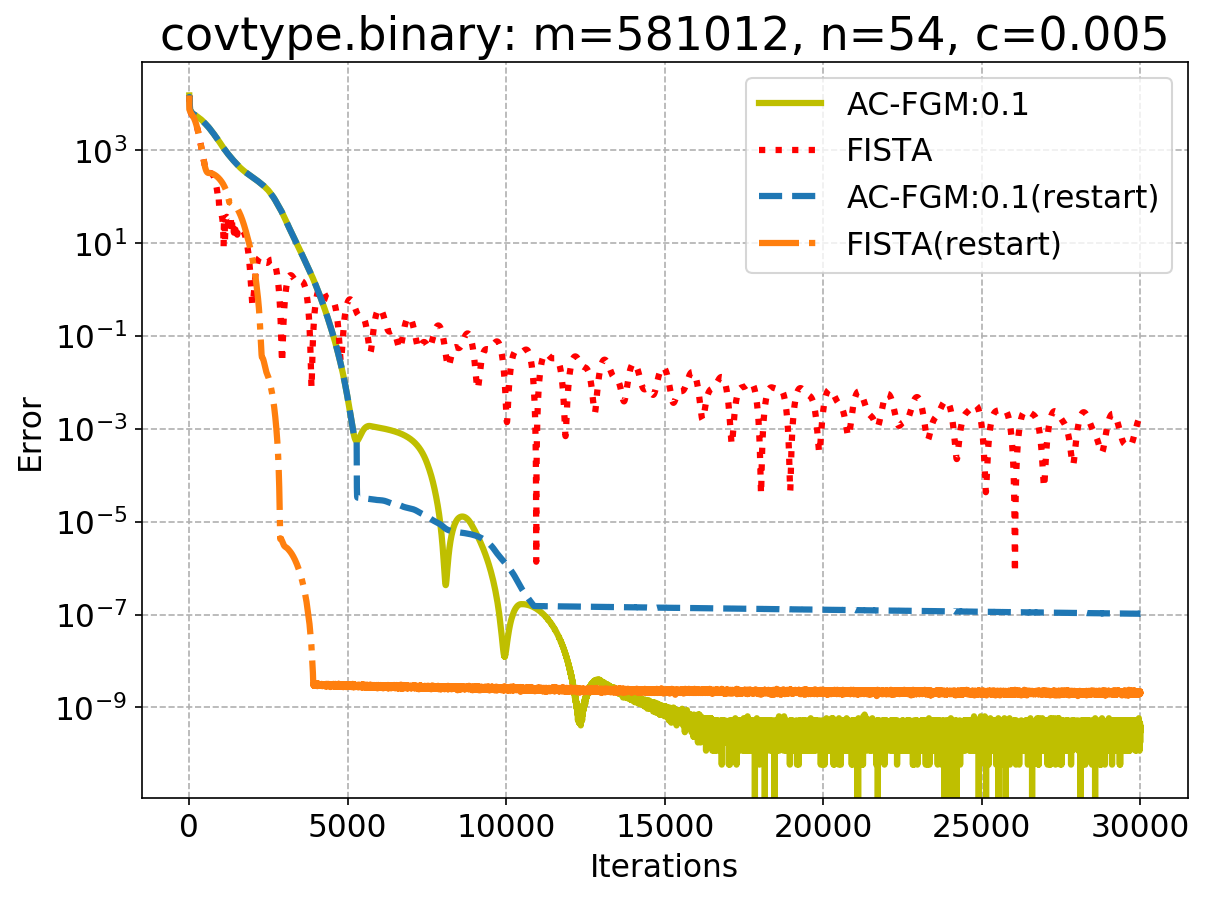

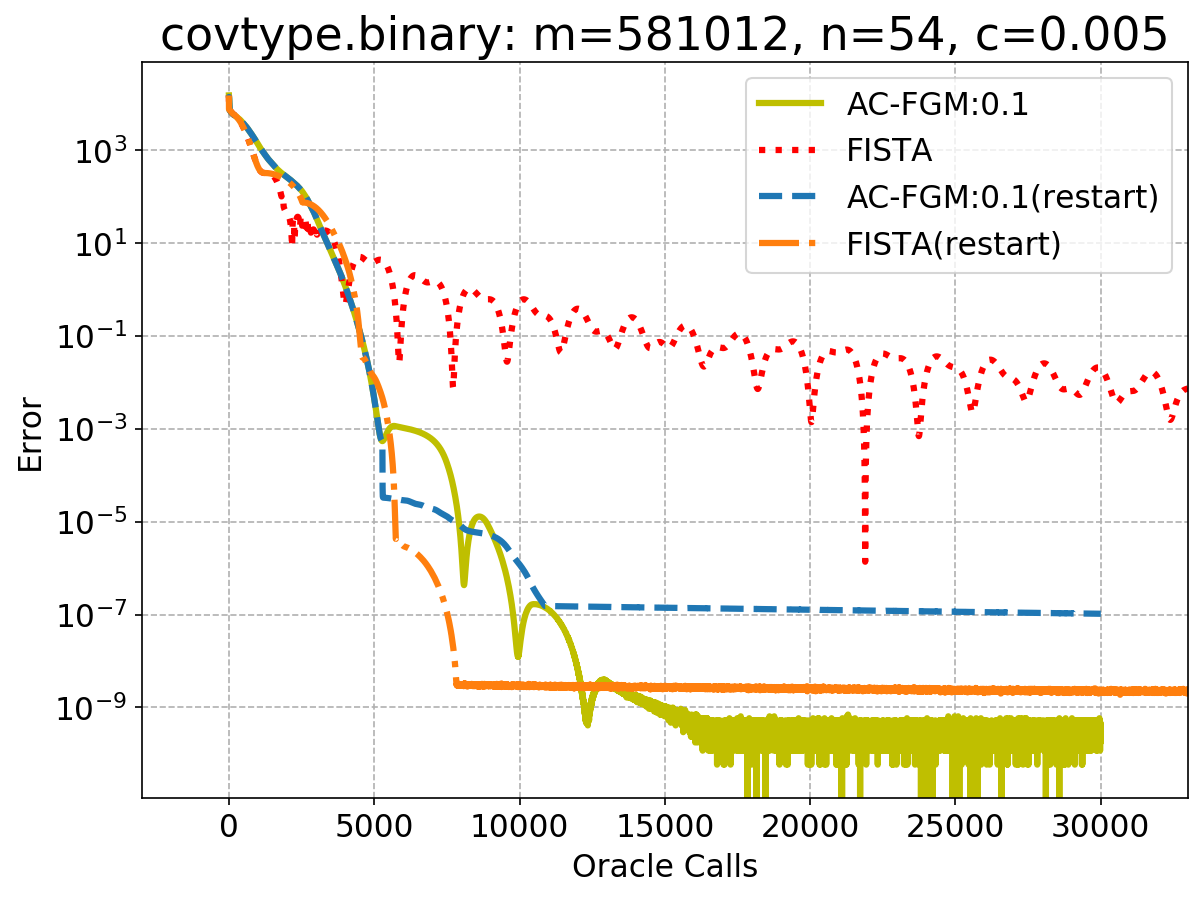

In [25]:
dataset = "covtype.binary"
c = 0.005
k = 30000
right_lim = 33000
title = "covtype.binary: m=581012, n=54, c=0.005"

print("========================")
A_raw, b_raw = fetch_libsvm(dataset)
b = (b_raw - 1.5) * 2
A = A_raw / np.max(A_raw)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_covtype_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_covtype_005_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_covtype_slr, f)

gamma: 10.861273
initial function value: 402726.829671
------------------------
AC-FGM: k=40000, alpha=0.100, beta=0.184
Done: 1578.175 seconds
-----------------------------------
FISTA: k=40000
Done: 3983.890 seconds
-----------------------------------
FISTA: k=40000
Done: 3987.622 seconds
-----------------------------------
AC-FGM: k=40000, alpha=0.100, beta=0.184
Done: 1580.494 seconds
-----------------------------------


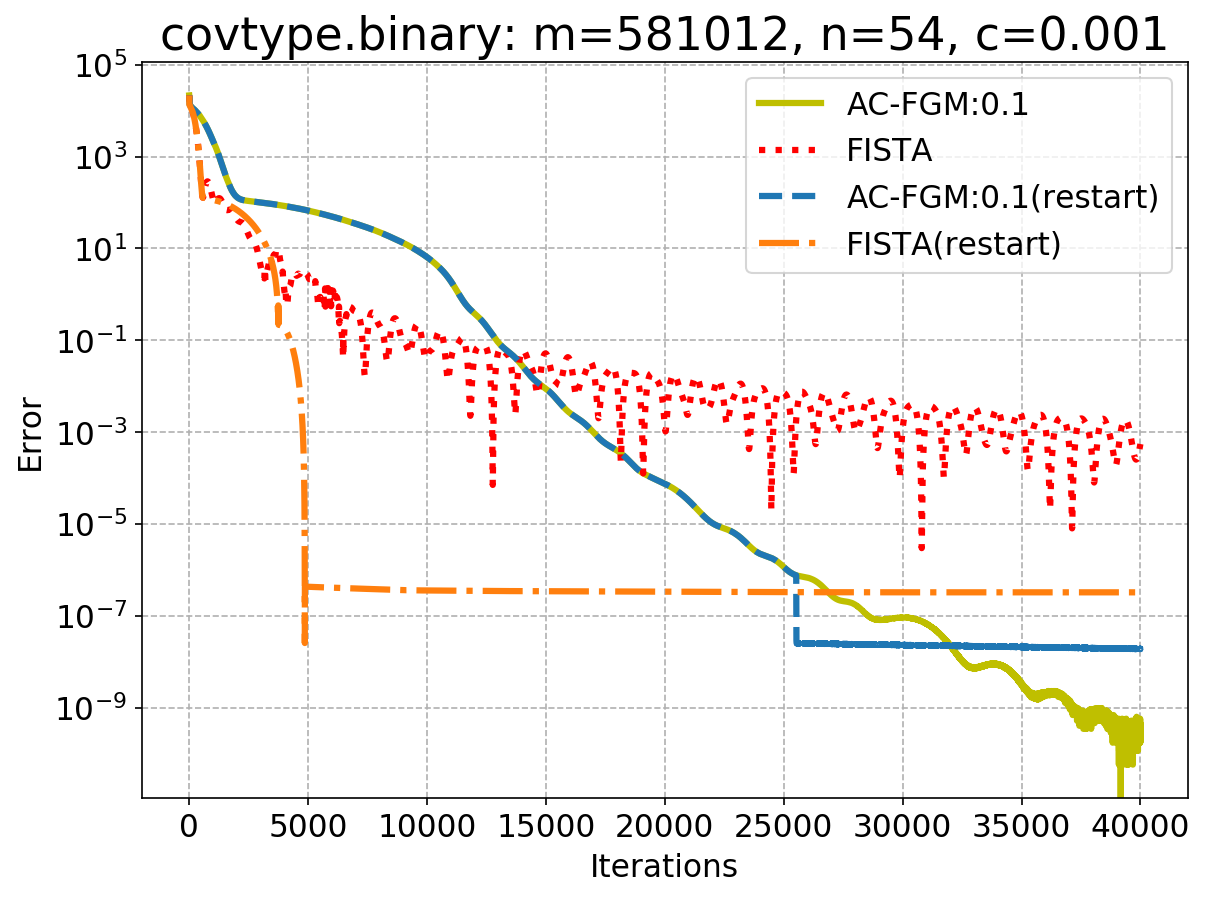

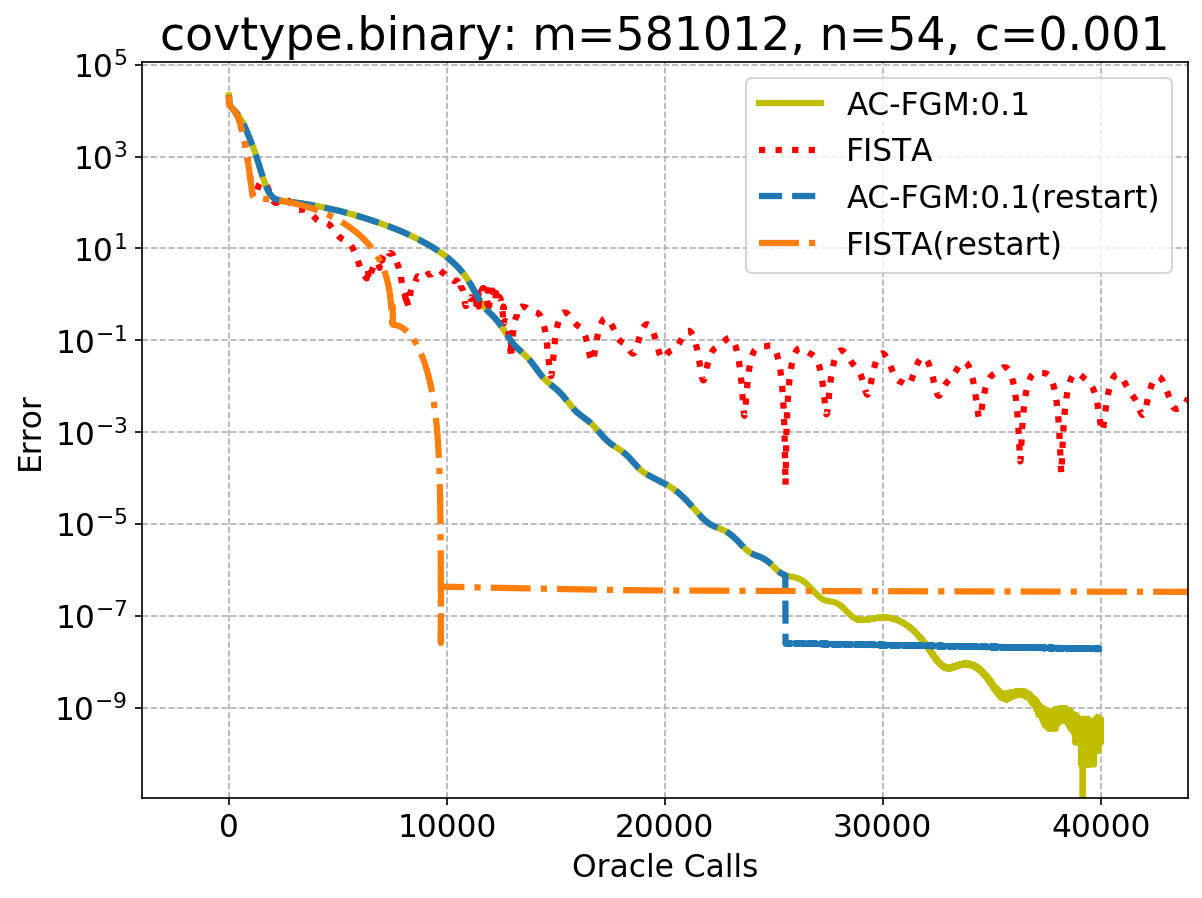

In [26]:
dataset = "covtype.binary"
c = 0.001
k = 40000
right_lim = 44000
title = "covtype.binary: m=581012, n=54, c=0.001"

print("========================")
A_raw, b_raw = fetch_libsvm(dataset)
b = (b_raw - 1.5) * 2
A = A_raw / np.max(A_raw)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_real_covtype_slr_2 = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_covtype_001_restart.pkl', 'wb') as f: 
    pickle.dump(result_real_covtype_slr_2, f)

sonar: m=208, n=60, c=0.001
gamma: 0.033035
initial function value: 144.174614
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 14.799 seconds
-----------------------------------
FISTA: k=20000
Done: 22.209 seconds
-----------------------------------
FISTA: k=20000
Done: 22.706 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 15.584 seconds
-----------------------------------


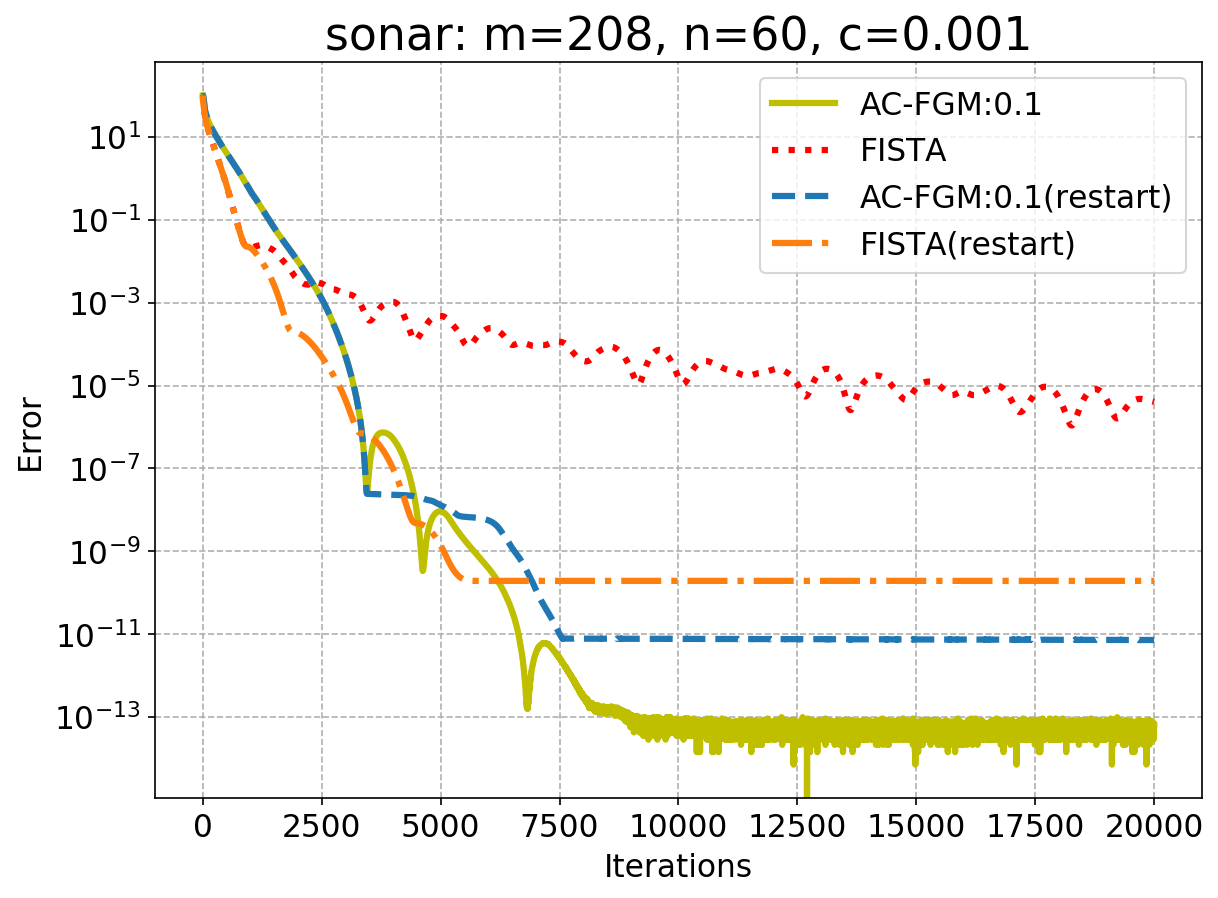

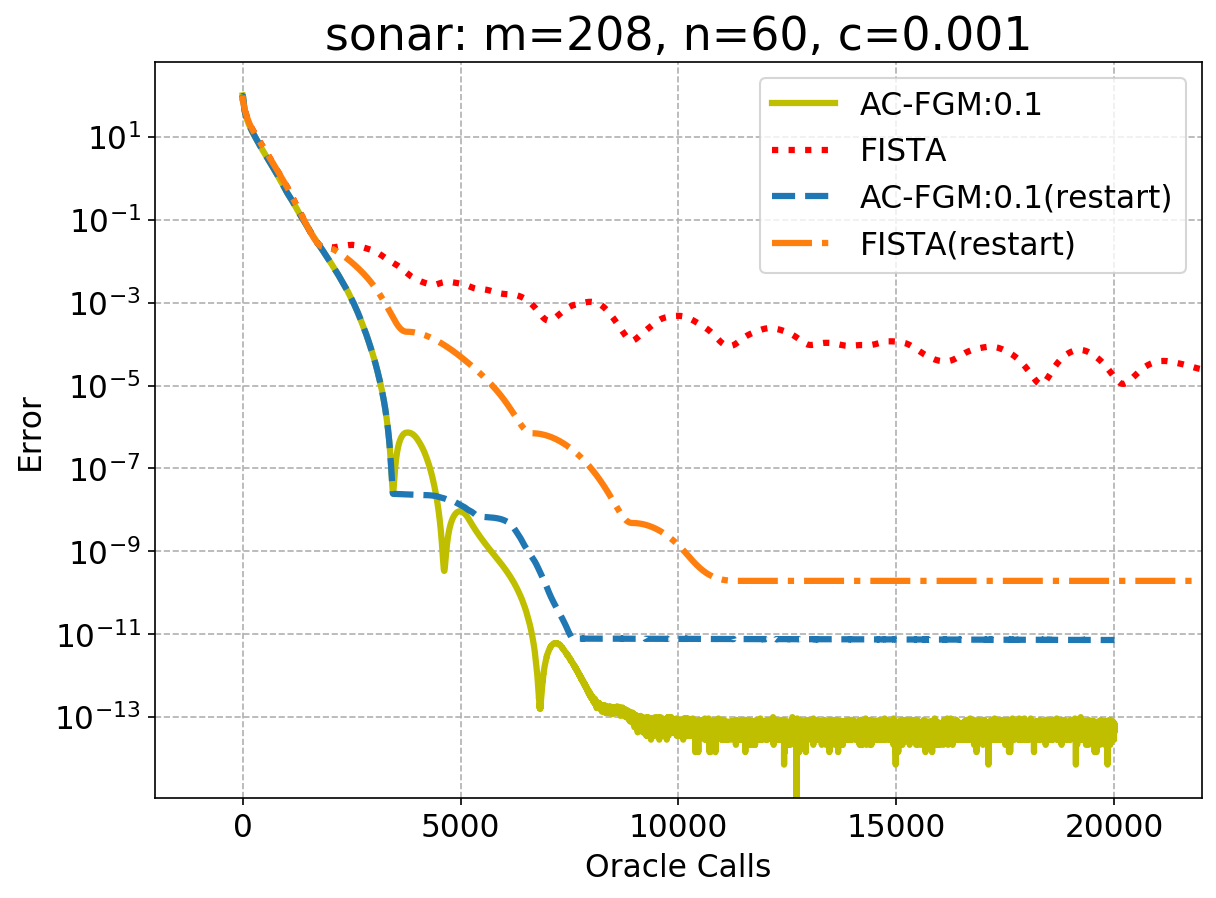

In [27]:
dataset = "sonar"
c = 0.001
k = 20000
right_lim = 22000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)

sonar: m=208, n=60, c=0.005
gamma: 0.165176
initial function value: 144.174614
------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 17.678 seconds
-----------------------------------
FISTA: k=20000
Done: 25.636 seconds
-----------------------------------
FISTA: k=20000
Done: 24.928 seconds
-----------------------------------
AC-FGM: k=20000, alpha=0.100, beta=0.184
Done: 17.173 seconds
-----------------------------------


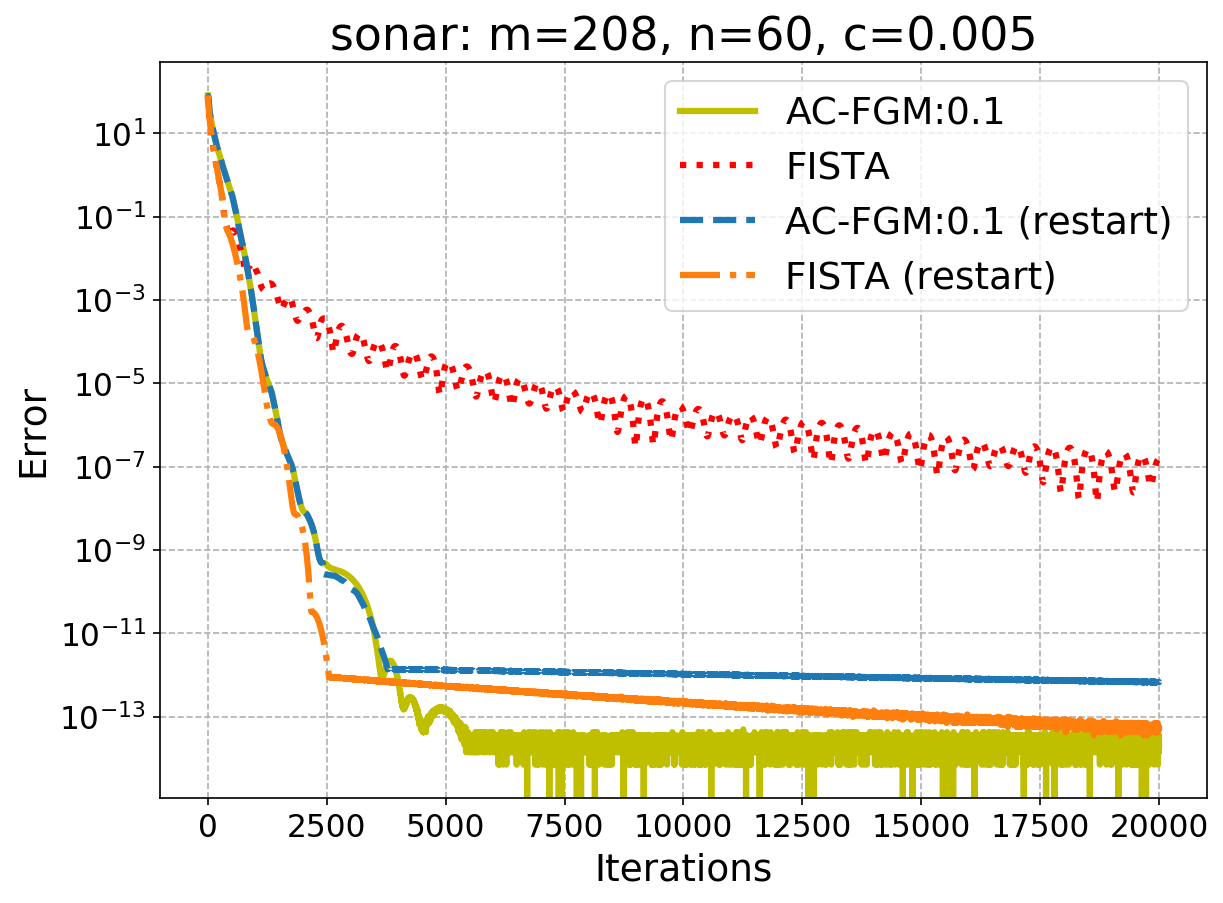

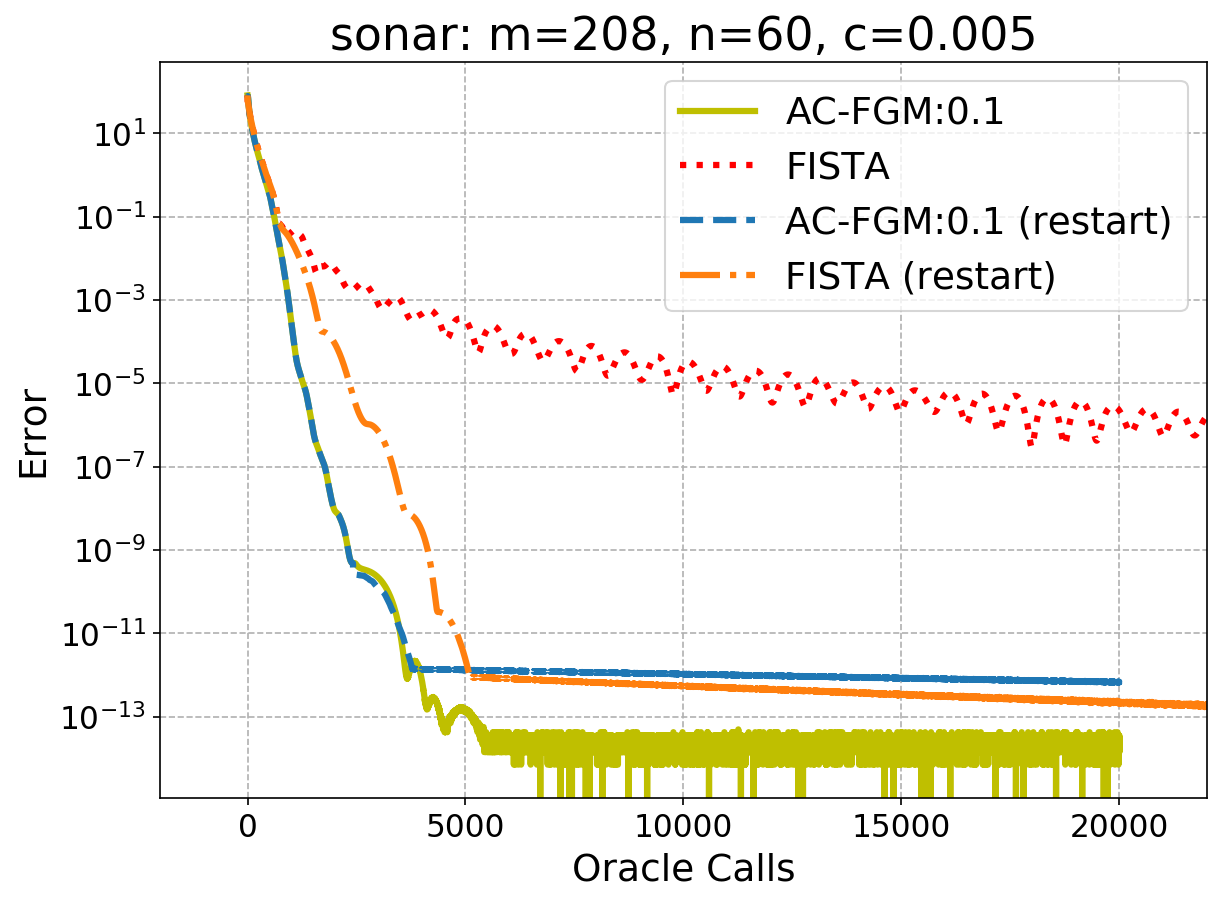

In [10]:
dataset = "sonar"
c = 0.005
k = 20000
right_lim = 22000

print("========================")
A, b = fetch_libsvm(dataset)
title = dataset + ": m=%d, n=%d, c=%.3f"%(A.shape[0], A.shape[1], c)
print(title)
slr = Sparse_Logistic_Regression(A, b, c)
print("gamma: %f"%slr.gamma)
fom = First_Order_Methods(slr)
print("initial function value: %f"%slr.objective(fom.x_0))
print("------------------------")
result_slr = fom.test_all_methods_smooth_adaptive_restart(k=k, beta=0.184, draw_performance_plot=True, dataset=title, initial_line_search=False, right_lim=right_lim)
with open('logistic_%s_%.3f_restart.pkl'%(dataset, c), 'wb') as f: 
    pickle.dump(result_slr, f)